In [221]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
#import kagglehub
#mahmoudelhemaly_students_grading_dataset_path = kagglehub.dataset_download('mahmoudelhemaly/students-grading-dataset')
#
#print('Data source import complete.')

<div style="text-align: center; background-color: #4CAF50; padding: 10px; border-radius: 10px;">
    <span style="color: white; font-size: 50px; font-weight: bold;">Student Performance & Behavior Analysis</span>
</div>

# **About Dataset**
---
- This dataset is real data of 5,000 records collected from a private learning provider. The dataset includes key attributes necessary for exploring patterns, correlations, and insights related to academic performance
---
### THis is the columns in dataSet: 
**Student_ID**: Unique identifier for each student.                                                     
**First_Name**: Student’s first name.                                                                   
**Last_Name**: Student’s last name.                                                                     
**Email**: Contact email (can be anonymized).                                                           
**Gender**: Male, Female, Other.                                                                     
**Age**: The age of the student.                                                                     
**Department**: Student's department (e.g., CS, Engineering, Business).                                 
**Attendance (%)**: Attendance percentage (0-100%).                                                     
**Midterm_Score**: Midterm exam score (out of 100).                                                     
**Final_Score**: Final exam score (out of 100).                                                         
**Assignments_Avg**: Average score of all assignments (out of 100).                                     
**Quizzes_Avg**: Average quiz scores (out of 100).                                                     
**Participation_Score**: Score based on class participation (0-10).                                  
**Projects_Score**: Project evaluation score (out of 100).                                              
**Total_Score**: Weighted sum of all grades.                                                     
**Grade**: Letter grade (A, B, C, D, F).                                                             
**Study_Hours_per_Week**: Average study hours per week.                                                 
**Extracurricular_Activities**: Whether the student participates in extracurriculars (Yes/No).          
**Internet_Access_at_Home**: Does the student have access to the internet at home? (Yes/No).           
**Parent_Education_Level**: Highest education level of parents (None, High School, Bachelor's, Master's, PhD).                                                                                  
**Family_Income_Level**: Low, Medium, High.                                                             
**Stress_Level (1-10)**: Self-reported stress level (1: Low, 10: High).                                 
**Sleep_Hours_per_Night**: Average hours of sleep per night.                                             

# Import libraries for using   


In [222]:
import pandas as pd # Required for data manipulation and analysis
import numpy as np # Required for mathematical operations
import matplotlib.pyplot as plt # Required for data visualization
import seaborn as sns # Required for statistical data visualization and exploration
import plotly.express as px # Required for interactive data visualization using plotly.express library
import plotly.graph_objects as go # Required for interactive data visualization using plotly.graph_objects library 
from sklearn.preprocessing import LabelEncoder # Required for label encoding categorical variables
from sklearn.feature_selection import mutual_info_regression # Required for mutual information analysis
from sklearn.model_selection import train_test_split# Required for splitting the dataset into training and testing sets
from sklearn.linear_model import LinearRegression # Required for linear regression analysis
from sklearn.tree import DecisionTreeRegressor # Required for decision tree regression
from sklearn.ensemble import RandomForestRegressor # Required for random forest regression
from sklearn.metrics import mean_squared_error, r2_score # Required for evaluating regression models
from sklearn.ensemble import RandomForestRegressor # Required for random forest regression
from sklearn.model_selection import RandomizedSearchCV # Required for randomized search cross-validation
#import tensorflow as tf
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import Dense, Dropout
from scipy.stats import ttest_ind
from scipy import stats
import math

# Data Cleaning and Peproccessing 

## load the data and Know information about it 

In [223]:
data = pd.read_csv('./Students_Grading_Dataset.csv' , index_col='Student_ID'  )
data.head() # Display the first 5 rows of the dataset

,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
Student_ID,,,,,,,,,,,,,,,,,,,,,
S1000,Omar,Williams,student0@university.com,Female,22,Engineering,52.29,55.03,57.82,84.22,...,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.27,97.23,45.80,NaN,...,55.65,50.64,A,19.0,No,Yes,NaN,Medium,4,9.0
S1002,Ahmed,Jones,student2@university.com,Male,24,Business,57.19,67.05,93.68,67.70,...,73.79,70.30,D,20.7,No,Yes,Master's,Low,6,6.2
S1003,Omar,Williams,student3@university.com,Female,24,Mathematics,95.15,47.79,80.63,66.06,...,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7
S1004,John,Smith,student4@university.com,Female,23,CS,54.18,46.59,78.89,96.85,...,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1


In [224]:
data.tail() # Display the last 5 rows of the dataset


,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
Student_ID,,,,,,,,,,,,,,,,,,,,,
S5995,Ahmed,Jones,student4995@university.com,Male,19,Business,NaN,82.15,60.33,80.09,...,58.42,85.21,D,25.5,No,Yes,High School,Low,10,8.3
S5996,Emma,Brown,student4996@university.com,Male,19,Business,65.11,86.31,49.80,NaN,...,60.87,95.96,C,5.0,No,Yes,NaN,Medium,4,4.0
S5997,John,Brown,student4997@university.com,Female,24,CS,87.54,63.55,64.21,94.28,...,82.65,54.25,A,24.8,Yes,No,High School,Medium,4,6.3
S5998,Sara,Davis,student4998@university.com,Male,23,CS,92.56,79.79,94.28,81.20,...,94.29,55.84,A,16.1,Yes,Yes,Bachelor's,Low,1,8.4
S5999,Maria,Brown,student4999@university.com,Female,21,Engineering,83.92,83.24,53.47,51.76,...,69.25,77.86,F,29.2,No,Yes,PhD,Low,2,6.1


In [225]:
data.shape # Display the number of rows and columns in the dataset

(5000, 22)

In [226]:
data.info() # Display information about the dataset including column names, data types, and number of non-null values

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, S1000 to S5999
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   First_Name                  5000 non-null   object 
 1   Last_Name                   5000 non-null   object 
 2   Email                       5000 non-null   object 
 3   Gender                      5000 non-null   object 
 4   Age                         5000 non-null   int64  
 5   Department                  5000 non-null   object 
 6   Attendance (%)              4484 non-null   float64
 7   Midterm_Score               5000 non-null   float64
 8   Final_Score                 5000 non-null   float64
 9   Assignments_Avg             4483 non-null   float64
 10  Quizzes_Avg                 5000 non-null   float64
 11  Participation_Score         5000 non-null   float64
 12  Projects_Score              5000 non-null   float64
 13  Total_Score                 5000 

In [227]:
data.describe() # Display statistical summary of the dataset including count, mean, standard deviation, minimum, and maximum values

,Age,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Study_Hours_per_Week,Stress_Level (1-10),Sleep_Hours_per_Night
count,5000.000000,4484.000000,5000.000000,5000.000000,4483.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000
mean,21.048400,75.431409,70.326844,69.640788,74.798673,74.910728,4.980024,74.924860,75.121804,17.658860,5.48080,6.488140
std,1.989786,14.372446,17.213209,17.238744,14.411799,14.504281,2.890136,14.423415,14.399941,7.275864,2.86155,1.452283
min,18.000000,50.010000,40.000000,40.000000,50.000000,50.030000,0.000000,50.010000,50.020000,5.000000,1.00000,4.000000
25%,19.000000,63.265000,55.457500,54.667500,62.090000,62.490000,2.440000,62.320000,62.835000,11.400000,3.00000,5.200000
50%,21.000000,75.725000,70.510000,69.735000,74.810000,74.695000,4.955000,74.980000,75.395000,17.500000,5.00000,6.500000
75%,23.000000,87.472500,84.970000,84.500000,86.970000,87.630000,7.500000,87.367500,87.652500,24.100000,8.00000,7.700000
max,24.000000,100.000000,99.980000,99.980000,99.980000,99.960000,10.000000,100.000000,99.990000,30.000000,10.00000,9.000000


In [228]:
#Identify categorical columns
category_columns = data.select_dtypes(include='object').columns
#Display number of categories and their counts in categorical columns
for col in category_columns:
    print(f'Column: {col}')
    print(f'It has {data[col].nunique()} categories')
    print(data[col].value_counts())
    print('\n')

Column: First_Name
It has 8 categories
First_Name
Maria    657
Ahmed    651
Ali      644
Emma     628
Sara     612
John     608
Omar     601
Liam     599
Name: count, dtype: int64


Column: Last_Name
It has 6 categories
Last_Name
Johnson     868
Jones       850
Davis       829
Brown       825
Smith       817
Williams    811
Name: count, dtype: int64


Column: Email
It has 5000 categories
Email
student4999@university.com    1
student0@university.com       1
student1@university.com       1
student2@university.com       1
student3@university.com       1
                             ..
student12@university.com      1
student11@university.com      1
student10@university.com      1
student9@university.com       1
student8@university.com       1
Name: count, Length: 5000, dtype: int64


Column: Gender
It has 2 categories
Gender
Male      2551
Female    2449
Name: count, dtype: int64


Column: Department
It has 4 categories
Department
CS             2022
Engineering    1469
Business       1006

## Check on missing values in the dataset

In [229]:
data.isnull().sum() # Display the number of missing values in each column of the dataset 

First_Name                       0
Last_Name                        0
Email                            0
Gender                           0
Age                              0
Department                       0
Attendance (%)                 516
Midterm_Score                    0
Final_Score                      0
Assignments_Avg                517
Quizzes_Avg                      0
Participation_Score              0
Projects_Score                   0
Total_Score                      0
Grade                            0
Study_Hours_per_Week             0
Extracurricular_Activities       0
Internet_Access_at_Home          0
Parent_Education_Level        1794
Family_Income_Level              0
Stress_Level (1-10)              0
Sleep_Hours_per_Night            0
dtype: int64

## Delete unnecessary columns from student dataSet

***Total_Score & Grade***
- These columns were removed because they were incorrectly calculated in the original dataset.
Instead, I recalculated the total score and assigned new grades using a more accurate method.
Keeping the old columns would only cause confusion and wouldn't add value to the analysis.
--- 
***Parent_Education_Level***
- This feature had a high percentage of missing values (≈35.88%).
Filling it with a statistical measure (mode) wouldn't be appropriate since parental education can vary significantly.
Instead of introducing potential bias or unreliable data, I chose to drop it entirely.
---
***Email***
- this column are not used in the analysis as it is information about the students and not about their performance.

In [230]:
# Create a copy of the dataset
data_clean = data.copy()



# Check data types after conversion
print(data_clean.dtypes)


First_Name                     object
Last_Name                      object
Email                          object
Gender                         object
Age                             int64
Department                     object
Attendance (%)                float64
Midterm_Score                 float64
Final_Score                   float64
Assignments_Avg               float64
Quizzes_Avg                   float64
Participation_Score           float64
Projects_Score                float64
Total_Score                   float64
Grade                          object
Study_Hours_per_Week          float64
Extracurricular_Activities     object
Internet_Access_at_Home        object
Parent_Education_Level         object
Family_Income_Level            object
Stress_Level (1-10)             int64
Sleep_Hours_per_Night         float64
dtype: object


In [231]:
# Drop unnecessary columns
data_clean = data_clean.drop(columns=["Email", "Total_Score", "Grade", "Parent_Education_Level"])

## Recalculating Total Score and Grade
- In this process, I recalculated the New_Total_Score and New_Grade because the existing values were incorrect. To ensure accuracy and alignment with common grading criteria used in most colleges, I applied the following steps:

**Final Score** (40%)
**Midterm Score** (20%)
**Projects Score** (15%)
**Assignments Average** (10%)
**Quizzes Average** (10%)
**Attendance** (2.5%)
**Participation Score** (2.5%)

**Handling Missing Values**: 
-If any value was missing for Assignments_Avg or Attendance (%), I replaced it with the column’s mean. This prevents bias from missing data while maintaining consistency in calculations.
**Computing the New Total Score**: Using the weighted sum of all the relevant components, I recalculated the New_Total_Score.
**Rounding Strategy**:
- If the decimal part of the score was 0.5 or higher, I rounded it up (ceil); otherwise, I rounded it down (floor).
**Assigning Grades**:
- Based on the new total score, I reassigned grades using standard grading cutoffs:
**A**: 90 and above
**B**: 80 - 89
**C**: 70 - 79
**D**: 60 - 69
**F**: Below 60


In [232]:
# Normalize Participation Score (out of 10 to 100 scale)
data_clean["Participation_Score"] = data_clean["Participation_Score"] * 10  # Convert to 100 scale

# Define weights
weights = {
    "Final_Score": 0.4,
    "Midterm_Score": 0.2,
    "Projects_Score": 0.15,
    "Assignments_Avg": 0.1,
    "Quizzes_Avg": 0.1,
    "Attendance (%)": 0.025,
    "Participation_Score": 0.025
}

# Compute column means
attendance_mean = data_clean["Attendance (%)"].mean()
assignments_mean = data_clean["Assignments_Avg"].mean()

# Identify valid rows
valid_rows = data_clean.dropna(subset=["Final_Score", "Midterm_Score", "Projects_Score", "Quizzes_Avg", "Participation_Score"]).index

# Compute Total Score only for valid rows, substituting NaNs with column means
data_clean.loc[valid_rows, "New_Total_Score"] = (
    data_clean.loc[valid_rows, "Final_Score"] * weights["Final_Score"] +
    data_clean.loc[valid_rows, "Midterm_Score"] * weights["Midterm_Score"] +
    data_clean.loc[valid_rows, "Projects_Score"] * weights["Projects_Score"] +
    data_clean.loc[valid_rows, "Assignments_Avg"].fillna(assignments_mean) * weights["Assignments_Avg"] +
    data_clean.loc[valid_rows, "Quizzes_Avg"] * weights["Quizzes_Avg"] +
    data_clean.loc[valid_rows, "Attendance (%)"].fillna(attendance_mean) * weights["Attendance (%)"] +
    data_clean.loc[valid_rows, "Participation_Score"] * weights["Participation_Score"]
)

# Round Total_Score (ceil if decimal ≥ 0.5, floor otherwise)
data_clean.loc[valid_rows, "New_Total_Score"] = data_clean.loc[valid_rows, "New_Total_Score"].apply(lambda x: np.ceil(x) if x % 1 >= 0.5 else np.floor(x))

# Assign New_Grades
def assign_New_Grade(score):
    if score >= 90:
        return "A"
    elif score >= 80:
        return "B"
    elif score >= 70:
        return "C"
    elif score >= 60:
        return "D"
    else:
        return "F"
data_clean.loc[valid_rows, "New_Grade"] = data_clean.loc[valid_rows, "New_Total_Score"].apply(assign_New_Grade)

# Display updated dataset
print(data_clean[["New_Total_Score", "New_Grade" , "Assignments_Avg" , "Attendance (%)" , "Department", "Midterm_Score" , "Final_Score","Projects_Score"]].head(10))


            New_Total_Score New_Grade  Assignments_Avg  Attendance (%)  \
Student_ID                                                               
S1000                  65.0         D            84.22           52.29   
S1001                  68.0         D              NaN           97.27   
S1002                  80.0         B            67.70           57.19   
S1003                  76.0         C            66.06           95.15   
S1004                  72.0         C            96.85           54.18   
S1005                  59.0         F            71.40             NaN   
S1006                  83.0         B            84.52           57.60   
S1007                  73.0         C            80.12           51.91   
S1008                  81.0         B            57.05           85.97   
S1009                  87.0         B            96.98           64.01   

             Department  Midterm_Score  Final_Score  Projects_Score  
Student_ID                               

In [233]:
data_clean['First_Name'].unique()

array(['Omar', 'Maria', 'Ahmed', 'John', 'Liam', 'Sara', 'Emma', 'Ali'],
      dtype=object)

In [234]:
for index, row in data_clean.iterrows():
    if row['First_Name'] in ('Omar', 'Ahmed', 'John', 'Liam','Ali'):
        data_clean.loc[index, 'Gender'] = 'Male'
    else:
        data_clean.loc[index, 'Gender'] = 'Female'

## Handing missing values in the student dataset
 we have a missing values in the 'Attendance (%)' = 516 'Assignments_Avg'=517 and 'Parent_Education_Level' = 1794
- just as I did with attendance, I applied the same approach to assignments by calculating the mean assignment scores for each (Department, New_Grade) group instead of using the overall mean.
- Different departments have different grading policies and coursework expectations.

- **Higher-performing students** (A, B grades) tend to have higher assignment averages, so filling missing values with a general mean could distort the dataset.

- Using department- and grade-based means ensures that the missing values align with real student performance trends.

In [235]:
# Calculate mean attendance for each (Department, New_Grade) group
att_means = data_clean.groupby(['Department', 'New_Grade'])['Attendance (%)'].mean()

# Display the means
print(att_means)

Department   New_Grade
Business     A            81.653333
             B            74.277115
             C            75.903262
             D            75.769770
             F            72.599844
CS           A            75.375556
             B            75.353730
             C            74.634911
             D            74.974255
             F            74.727019
Engineering  A            78.848750
             B            74.913450
             C            76.511039
             D            76.819493
             F            73.540440
Mathematics  A            80.276667
             B            75.371923
             C            74.605625
             D            76.224114
             F            78.097250
Name: Attendance (%), dtype: float64


In [236]:
# Calculate mean attendance for each (Department, New_Grade) group
assignment_means = data_clean.groupby(['Department', 'New_Grade'])['Assignments_Avg'].mean()

# Display the means
print(assignment_means)


Department   New_Grade
Business     A            81.832500
             B            77.799155
             C            75.917135
             D            74.201424
             F            68.894118
CS           A            80.431429
             B            78.405596
             C            76.620193
             D            74.027594
             F            67.969273
Engineering  A            88.103333
             B            78.045411
             C            74.566191
             D            72.264489
             F            70.207041
Mathematics  A            88.565000
             B            81.536076
             C            72.790194
             D            71.938780
             F            71.688250
Name: Assignments_Avg, dtype: float64


In [237]:
data_clean['Attendance (%)'] = data_clean.apply(
    lambda row: att_means[row['Department'], row['New_Grade']] if pd.isna(row['Attendance (%)']) else row['Attendance (%)'],
    axis=1
)
data_clean['Assignments_Avg'] = data_clean.apply(
    lambda row: assignment_means[row['Department'], row['New_Grade']] if pd.isna(row['Assignments_Avg']) else row['Assignments_Avg'],
    axis=1
)


In [238]:
print(data_clean[["New_Total_Score", "New_Grade" , "Assignments_Avg" , "Attendance (%)" , "Department", "Midterm_Score" , "Final_Score","Projects_Score"]].head(10))

            New_Total_Score New_Grade  Assignments_Avg  Attendance (%)  \
Student_ID                                                               
S1000                  65.0         D        84.220000        52.29000   
S1001                  68.0         D        72.264489        97.27000   
S1002                  80.0         B        67.700000        57.19000   
S1003                  76.0         C        66.060000        95.15000   
S1004                  72.0         C        96.850000        54.18000   
S1005                  59.0         F        71.400000        73.54044   
S1006                  83.0         B        84.520000        57.60000   
S1007                  73.0         C        80.120000        51.91000   
S1008                  81.0         B        57.050000        85.97000   
S1009                  87.0         B        96.980000        64.01000   

             Department  Midterm_Score  Final_Score  Projects_Score  
Student_ID                               

In [239]:
data_clean.isnull().sum() # Display the number of missing values in each column of the dataset

First_Name                    0
Last_Name                     0
Gender                        0
Age                           0
Department                    0
Attendance (%)                0
Midterm_Score                 0
Final_Score                   0
Assignments_Avg               0
Quizzes_Avg                   0
Participation_Score           0
Projects_Score                0
Study_Hours_per_Week          0
Extracurricular_Activities    0
Internet_Access_at_Home       0
Family_Income_Level           0
Stress_Level (1-10)           0
Sleep_Hours_per_Night         0
New_Total_Score               0
New_Grade                     0
dtype: int64

make the columns in true dtype

In [240]:
# Convert object columns to categorical type
catego_columns = ["Department", "Gender","New_Grade","First_Name","Last_Name"]
for col in catego_columns:
    data_clean[col] = data_clean[col].astype('category')

## Data Quality:
Check on duplicated values in the dataset

In [241]:
print(data_clean.duplicated().sum()) # Display the number of duplicated rows in the dataset

0


In [242]:
data_clean = data_clean.drop_duplicates()
print(data_clean.duplicated().sum())

0


No duplicated values found in the dataset.

In [243]:
data_clean.info() #check again for data info

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, S1000 to S5999
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   First_Name                  5000 non-null   category
 1   Last_Name                   5000 non-null   category
 2   Gender                      5000 non-null   category
 3   Age                         5000 non-null   int64   
 4   Department                  5000 non-null   category
 5   Attendance (%)              5000 non-null   float64 
 6   Midterm_Score               5000 non-null   float64 
 7   Final_Score                 5000 non-null   float64 
 8   Assignments_Avg             5000 non-null   float64 
 9   Quizzes_Avg                 5000 non-null   float64 
 10  Participation_Score         5000 non-null   float64 
 11  Projects_Score              5000 non-null   float64 
 12  Study_Hours_per_Week        5000 non-null   float64 
 13  Extracurricular_Ac

In [244]:
data_clean.shape

(5000, 20)

## check on outliers values 

**IQR (Interquartile Range) Method**: Outliers are values outside the range
[
𝑄
1
−
1.5
×
𝐼
𝑄
𝑅
,
𝑄
3
+
1.5
×
𝐼
𝑄
𝑅
]
[Q1−1.5×IQR,Q3+1.5×IQR].


**Z-Score Method**: Outliers are values with a Z-score **greater** than **3** or **less** than **-3**.

Boxplots: A quick visual way to identify outliers.

Distribution Plots: Help in spotting extreme values.


***Detect Outliers Using IQR & Z-Score***

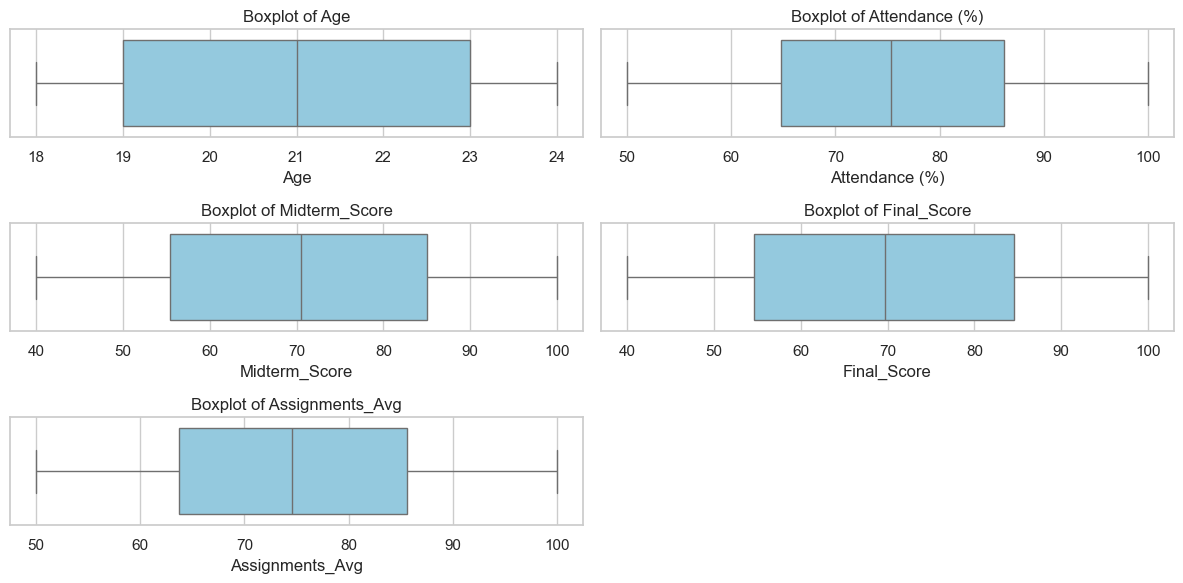

In [245]:
numerical_cols = ["Age", "Attendance (%)", "Midterm_Score", "Final_Score", "Assignments_Avg"]
plt.figure(figsize=(12, 6))

# Boxplot for outlier detection
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(x=data_clean[col], color="skyblue")
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

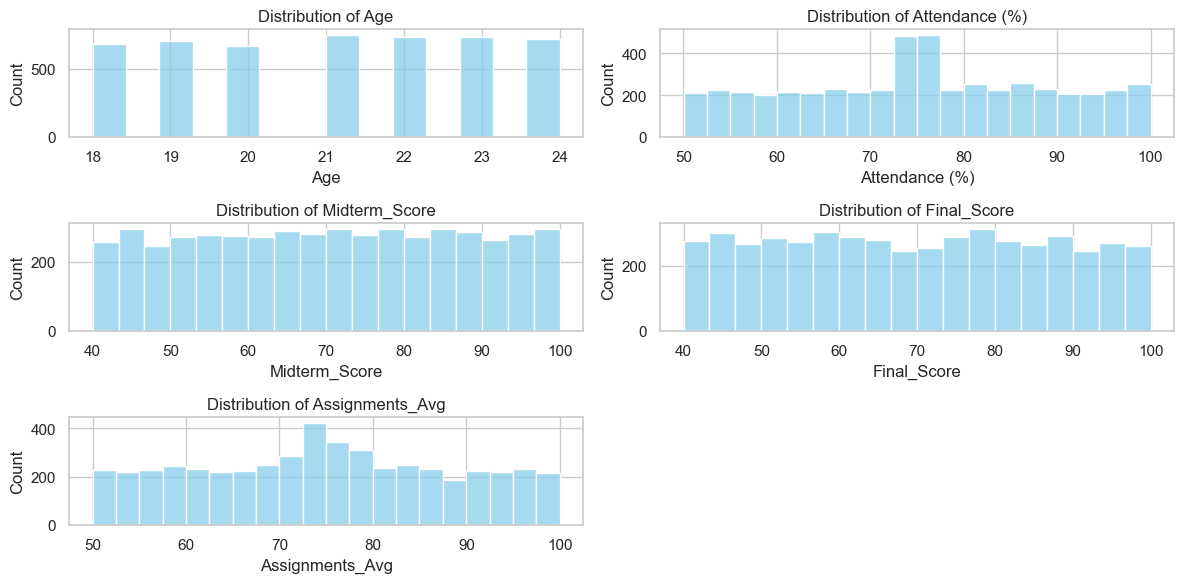

In [246]:
numerical_cols = ["Age", "Attendance (%)", "Midterm_Score", "Final_Score", "Assignments_Avg"]
plt.figure(figsize=(12, 6))

# Boxplot for outlier detection
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 2, i)
    sns.histplot(x=data_clean[col], color="skyblue")
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

no outlier in the numircal distribution of data from visualization tools

In [247]:
# Ensure numericals_columns contains only numerical columns
numericals_columns = data_clean.select_dtypes(include=['number']).columns
outliers_iqr = {}
outliers_zscore = {}
for col in numericals_columns:
    if data_clean[col].nunique() > 1:  # Skip columns with only one unique value
        Q1 = data_clean[col].quantile(0.25)
        Q3 = data_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers_iqr[col] = data_clean[(data_clean[col] < lower_bound) | (data_clean[col] > upper_bound)][col]

        mean = data_clean[col].mean()
        std = data_clean[col].std()
        z_scores = (data_clean[col] - mean) / std
        outliers_zscore[col] = data_clean[np.abs(z_scores) > 3][col]  # Z-score threshold of 3

# Check if any column has detected outliers
outlier_summary = {
    col: {"IQR Outliers": len(outliers_iqr[col]), "Z-Score Outliers": len(outliers_zscore[col])}
    for col in numericals_columns if col in outliers_iqr and col in outliers_zscore
}

# Convert summary to DataFrame
outlier_summary_data_clean = pd.DataFrame.from_dict(outlier_summary, orient="index")

# Display result
print(outlier_summary_data_clean)


                       IQR Outliers  Z-Score Outliers
Age                               0                 0
Attendance (%)                    0                 0
Midterm_Score                     0                 0
Final_Score                       0                 0
Assignments_Avg                   0                 0
Quizzes_Avg                       0                 0
Participation_Score               0                 0
Projects_Score                    0                 0
Study_Hours_per_Week              0                 0
Stress_Level (1-10)               0                 0
Sleep_Hours_per_Night             0                 0
New_Total_Score                   0                 0


In [248]:
data_clean

,First_Name,Last_Name,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night,New_Total_Score,New_Grade
Student_ID,,,,,,,,,,,,,,,,,,,,
S1000,Omar,Williams,Male,22,Engineering,52.290000,55.03,57.82,84.220000,74.06,39.9,85.90,6.2,No,Yes,Medium,5,4.7,65.0,D
S1001,Maria,Brown,Female,18,Engineering,97.270000,97.23,45.80,72.264489,94.24,83.2,55.65,19.0,No,Yes,Medium,4,9.0,68.0,D
S1002,Ahmed,Jones,Male,24,Business,57.190000,67.05,93.68,67.700000,85.70,50.5,73.79,20.7,No,Yes,Low,6,6.2,80.0,B
S1003,Omar,Williams,Male,24,Mathematics,95.150000,47.79,80.63,66.060000,93.51,65.4,92.12,24.8,Yes,Yes,High,3,6.7,76.0,C
S1004,John,Smith,Male,23,CS,54.180000,46.59,78.89,96.850000,83.70,59.7,68.42,15.4,Yes,Yes,High,2,7.1,72.0,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S5995,Ahmed,Jones,Male,19,Business,75.903262,82.15,60.33,80.090000,99.32,50.0,58.42,25.5,No,Yes,Low,10,8.3,70.0,C
S5996,Emma,Brown,Female,19,Business,65.110000,86.31,49.80,74.201424,88.08,27.9,60.87,5.0,No,Yes,Medium,4,4.0,65.0,D
S5997,John,Brown,Male,24,CS,87.540000,63.55,64.21,94.280000,50.19,31.3,82.65,24.8,Yes,No,Medium,4,6.3,68.0,D


## encoding necessary columns for machine learning model
### Machine learning models and numerical analysis require categorical data to be converted into numbers.

🛠 Solution:
One-Hot Encoding for non-ordinal categories (e.g., Gender, Department).
Label Encoding for ordinal categories (e.g., Parent_Education_Level).
python
Copy
Edit


use a label encoder to encode the 'family_income_level' column and "New_grade" column  into numerical values
 as must be ordered 

check for departments and students in it to ensure we must encoding it or no 

C:\Users\DELL\AppData\Local\Temp\ipykernel_19004\1528569314.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=department_counts.index, y=department_counts.values, palette="viridis", order=department_counts.index)


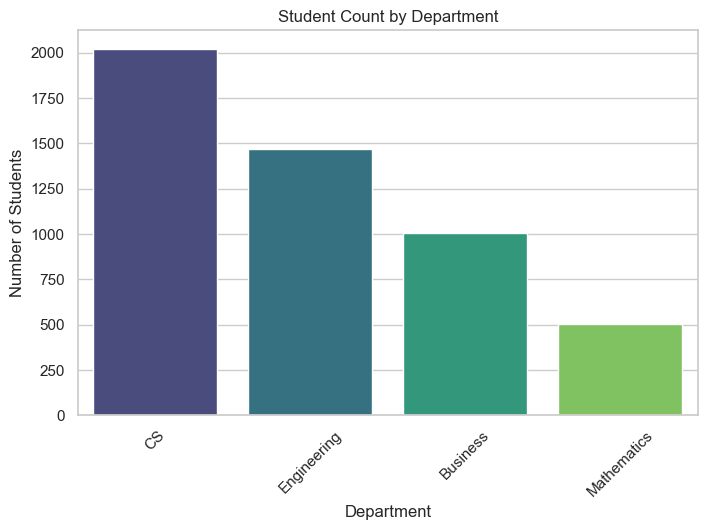

In [249]:
# Count the number of students in each department and sort
department_counts = data_clean["Department"].value_counts().sort_values(ascending=False)

# Create bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x=department_counts.index, y=department_counts.values, palette="viridis", order=department_counts.index)

# Formatting
plt.xlabel("Department")
plt.ylabel("Number of Students")
plt.title("Student Count by Department")
plt.xticks(rotation=45)

# Show the plot
plt.show()


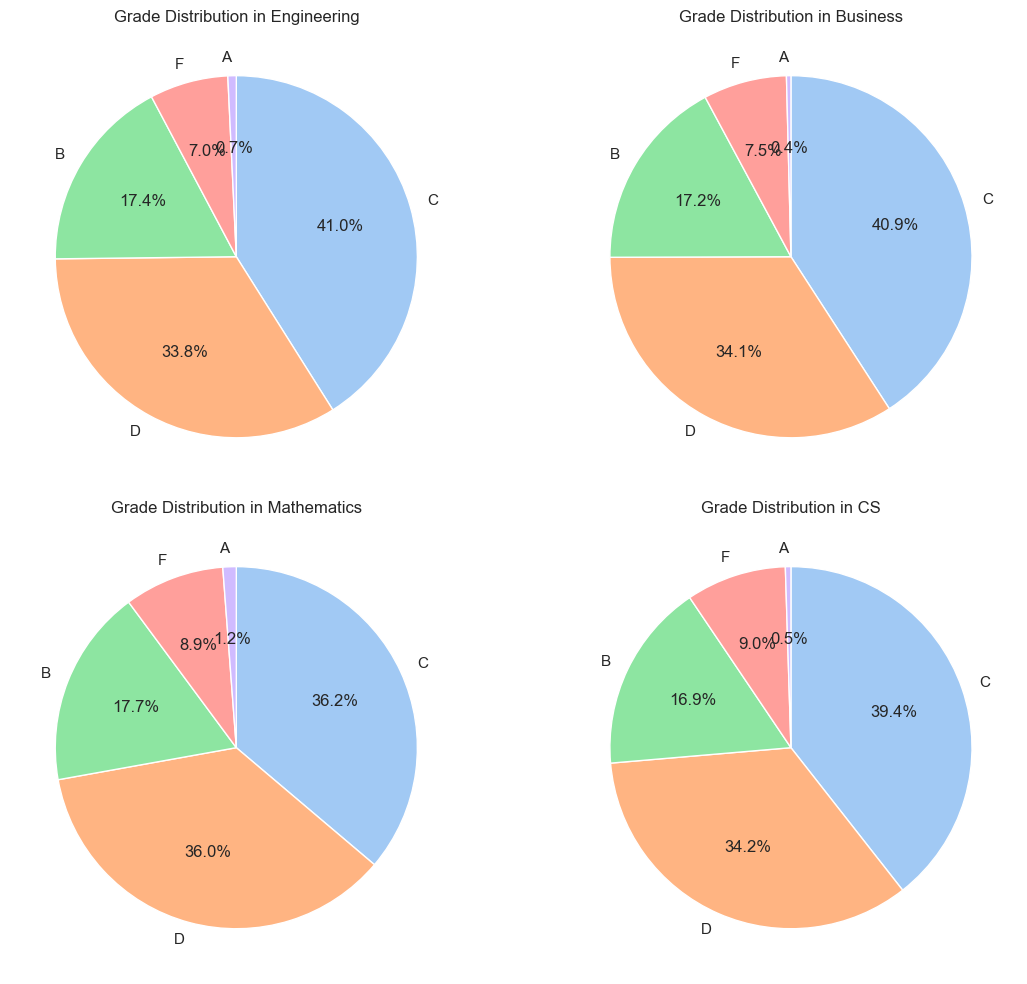

In [250]:
data_clean["Letter_Grade"] = data_clean["New_Grade"]

# Get unique departments
departments = data_clean["Department"].unique()
num_depts = len(departments)

# Set up a grid with 2 columns
rows = math.ceil(num_depts / 2)
fig, axes = plt.subplots(rows, 2, figsize=(12, 5 * rows))

# Flatten axes in case of a single row
axes = axes.flatten()

# Loop through each department and create a pie chart
for i, dept in enumerate(departments):
    grade_counts = data_clean[data_clean["Department"] == dept]["Letter_Grade"].value_counts()

    # Sort the slices (grades) by percentage in descending order
    grade_counts = grade_counts.sort_values(ascending=False)

    # Create a pie chart with sorted slices
    wedges, texts, autotexts = axes[i].pie(
        grade_counts, labels=grade_counts.index, autopct="%1.1f%%",
        colors=sns.color_palette("pastel"), startangle=90, counterclock=False
    )

    # Set title
    axes[i].set_title(f"Grade Distribution in {dept}")


# Adjust layout and show plots
plt.tight_layout()
plt.show()


if we encoding departments we miss one of department then it is not necessary to do it 

In [251]:
le = LabelEncoder()
data_clean["Family_Income_Level"] = le.fit_transform(data_clean["Family_Income_Level"])

In [252]:
data_clean["New_Grade"] = le.fit_transform(data_clean["New_Grade"])

use the One-Hot Encoding to encode the 'Extracurricular_Activities ' column and 'Internet_Access_at_Home ' column  and  'Gender' column into numerical values

In [253]:
data_clean = pd.get_dummies(data_clean, columns=["Gender", "Extracurricular_Activities","Internet_Access_at_Home"], drop_first=True)


## the clean Data information 

check the data info after encoding 

In [254]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, S1000 to S5999
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   First_Name                      5000 non-null   category
 1   Last_Name                       5000 non-null   category
 2   Age                             5000 non-null   int64   
 3   Department                      5000 non-null   category
 4   Attendance (%)                  5000 non-null   float64 
 5   Midterm_Score                   5000 non-null   float64 
 6   Final_Score                     5000 non-null   float64 
 7   Assignments_Avg                 5000 non-null   float64 
 8   Quizzes_Avg                     5000 non-null   float64 
 9   Participation_Score             5000 non-null   float64 
 10  Projects_Score                  5000 non-null   float64 
 11  Study_Hours_per_Week            5000 non-null   float64 
 12  Family_Income_Level 

In [255]:
data_clean.head()

,First_Name,Last_Name,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,...,Study_Hours_per_Week,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night,New_Total_Score,New_Grade,Letter_Grade,Gender_Male,Extracurricular_Activities_Yes,Internet_Access_at_Home_Yes
Student_ID,,,,,,,,,,,,,,,,,,,,,
S1000,Omar,Williams,22,Engineering,52.29,55.03,57.82,84.220000,74.06,39.9,...,6.2,2,5,4.7,65.0,3,D,True,False,True
S1001,Maria,Brown,18,Engineering,97.27,97.23,45.80,72.264489,94.24,83.2,...,19.0,2,4,9.0,68.0,3,D,False,False,True
S1002,Ahmed,Jones,24,Business,57.19,67.05,93.68,67.700000,85.70,50.5,...,20.7,1,6,6.2,80.0,1,B,True,False,True
S1003,Omar,Williams,24,Mathematics,95.15,47.79,80.63,66.060000,93.51,65.4,...,24.8,0,3,6.7,76.0,2,C,True,True,True
S1004,John,Smith,23,CS,54.18,46.59,78.89,96.850000,83.70,59.7,...,15.4,0,2,7.1,72.0,2,C,True,True,True


# Exploratory Data analysis (EDA)

- During the EDA process, I explored various aspects of the dataset to extract meaningful insights. However, I did not visualize all features due to inconsistencies in some of the data.


In [256]:
# Summary statistics
data_clean.describe()


,Age,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Study_Hours_per_Week,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night,New_Total_Score,New_Grade
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000
mean,21.048400,75.432148,70.326844,69.640788,74.818204,74.910728,49.80024,74.924860,17.658860,1.185800,5.48080,6.488140,71.265600,2.319600
std,1.989786,13.614962,17.213209,17.238744,13.675542,14.504281,28.90136,14.423415,7.275864,0.754316,2.86155,1.452283,8.303954,0.872014
min,18.000000,50.010000,40.000000,40.000000,50.000000,50.030000,0.00000,50.010000,5.000000,0.000000,1.00000,4.000000,48.000000,0.000000
25%,19.000000,64.737500,55.457500,54.667500,63.687500,62.490000,24.40000,62.320000,11.400000,1.000000,3.00000,5.200000,65.000000,2.000000
50%,21.000000,75.371923,70.510000,69.735000,74.566191,74.695000,49.55000,74.980000,17.500000,1.000000,5.00000,6.500000,71.000000,2.000000
75%,23.000000,86.182500,84.970000,84.500000,85.592500,87.630000,75.00000,87.367500,24.100000,2.000000,8.00000,7.700000,78.000000,3.000000
max,24.000000,100.000000,99.980000,99.980000,99.980000,99.960000,100.00000,100.000000,30.000000,2.000000,10.00000,9.000000,94.000000,4.000000


Correlation Heatmap (Finding Relationships)


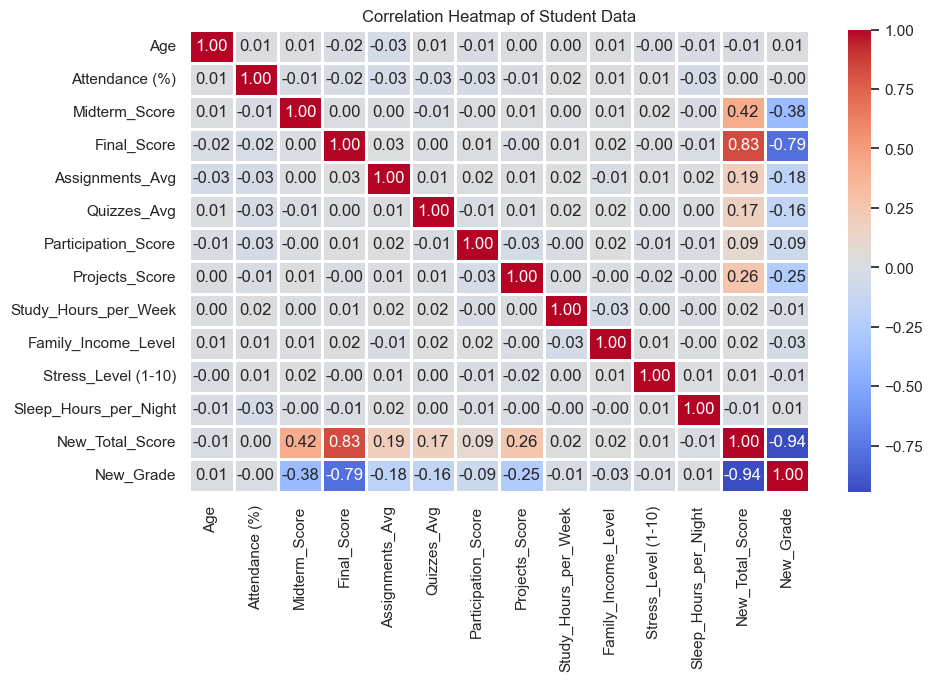

In [257]:

# Select only numeric columns
numeric_data_clean = data_clean.select_dtypes(include=['number'])

# Compute correlation matrix
plt.figure(figsize=(10,6))
sns.heatmap(numeric_data_clean.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=1)
plt.title("Correlation Heatmap of Student Data")
plt.show()


Week correlation in heatmap then we show different correlation methods 

#### **Interpreting Spearman Correlation (ρ)**
 **• ρ = +1 → Perfect positive monotonic relationship**
 
 **• ρ = -1 → Perfect negative monotonic relationship**
 
 **• ρ ≈ 0 → No monotonic relationship**

In [258]:
spearman_corr=numeric_data_clean.corr(method='spearman')
# Use Spearman correlation

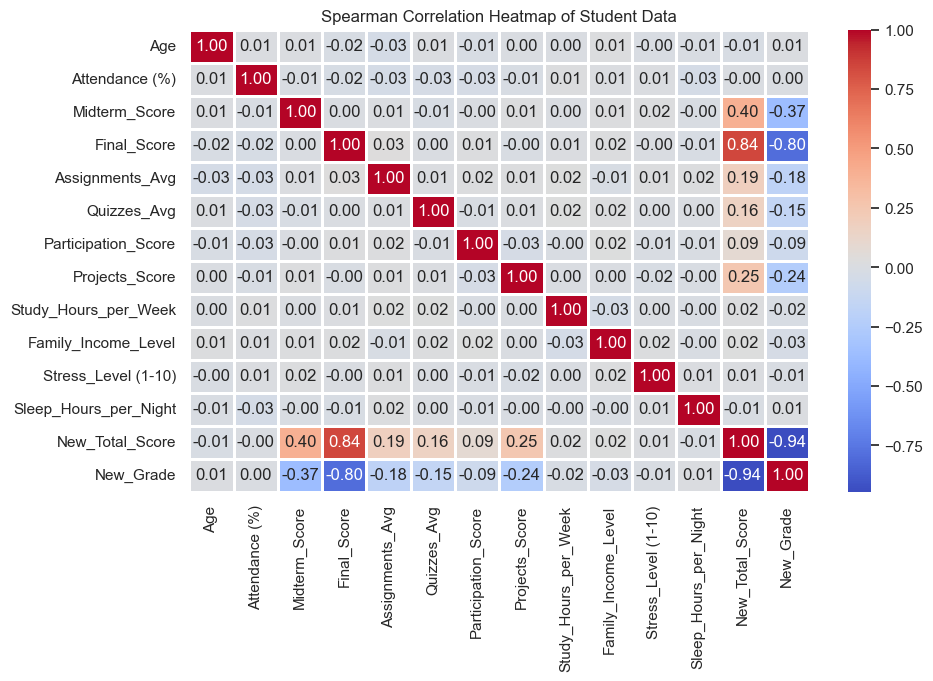

In [259]:
# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=1)

plt.title("Spearman Correlation Heatmap of Student Data")
plt.show()

In [260]:

Kendall_corr=numeric_data_clean.corr(method='kendall')  # Use Kendall correlation


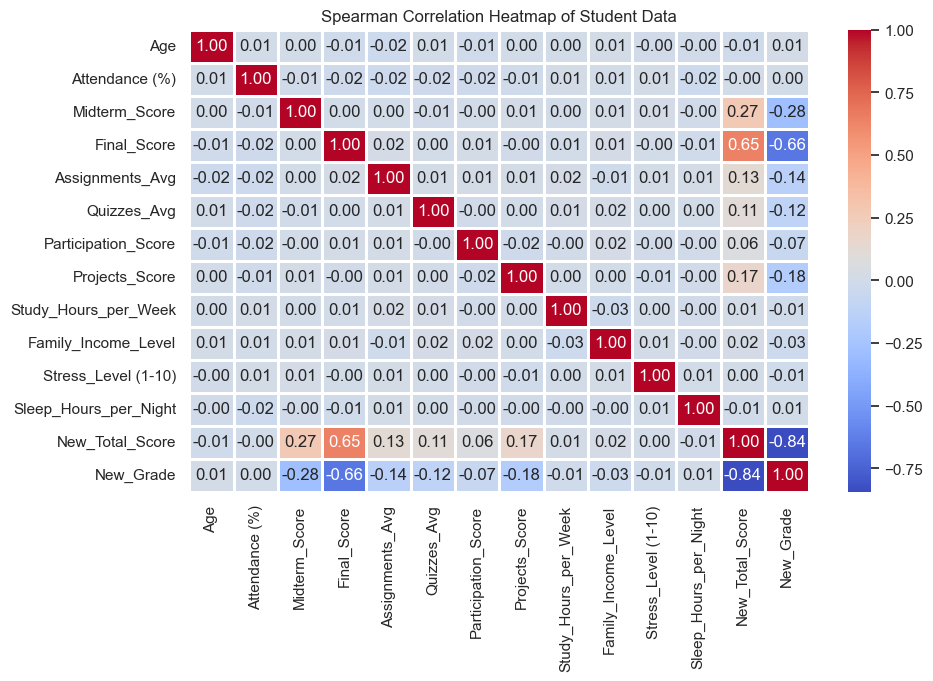

In [261]:
# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(Kendall_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=1)

plt.title("Spearman Correlation Heatmap of Student Data")
plt.show()

after checking the correlation heatmap we can say that the data is not linearly related                                                                   
-Helps identify strong relationships                                                                                                                    
-Most of the correlations are weak (close to 0) meaning the relationships between variables are not strong
-So accuracy will be bad

## data Visualization

In [262]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, S1000 to S5999
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   First_Name                      5000 non-null   category
 1   Last_Name                       5000 non-null   category
 2   Age                             5000 non-null   int64   
 3   Department                      5000 non-null   category
 4   Attendance (%)                  5000 non-null   float64 
 5   Midterm_Score                   5000 non-null   float64 
 6   Final_Score                     5000 non-null   float64 
 7   Assignments_Avg                 5000 non-null   float64 
 8   Quizzes_Avg                     5000 non-null   float64 
 9   Participation_Score             5000 non-null   float64 
 10  Projects_Score                  5000 non-null   float64 
 11  Study_Hours_per_Week            5000 non-null   float64 
 12  Family_Income_Level 

Avarage final score by departments

C:\Users\DELL\AppData\Local\Temp\ipykernel_19004\472408051.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_scores = data_clean.groupby("Department")["Final_Score"].mean().sort_values(ascending=False)  # Sort in descending order
C:\Users\DELL\AppData\Local\Temp\ipykernel_19004\472408051.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_scores.index, y=avg_scores.values, palette="magma")


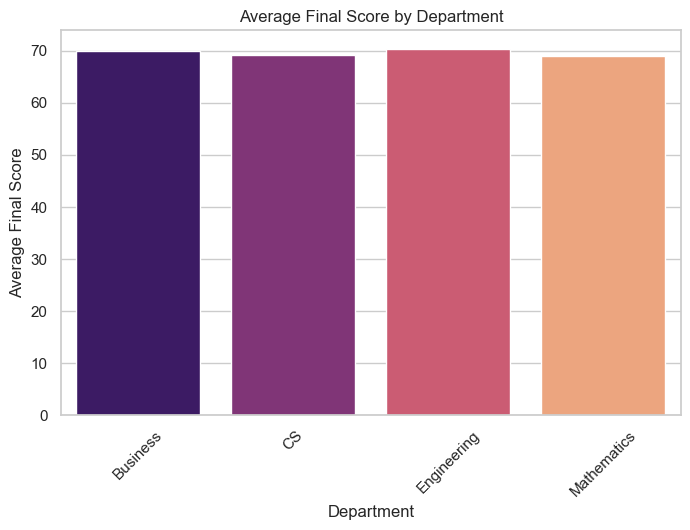

In [263]:
plt.figure(figsize=(8, 5))
avg_scores = data_clean.groupby("Department")["Final_Score"].mean().sort_values(ascending=False)  # Sort in descending order
sns.barplot(x=avg_scores.index, y=avg_scores.values, palette="magma")
plt.xticks(rotation=45)
plt.title("Average Final Score by Department")
plt.ylabel("Average Final Score")
plt.xlabel("Department")
plt.show()


Histplot
Displays the distribution of numerical columns using histograms

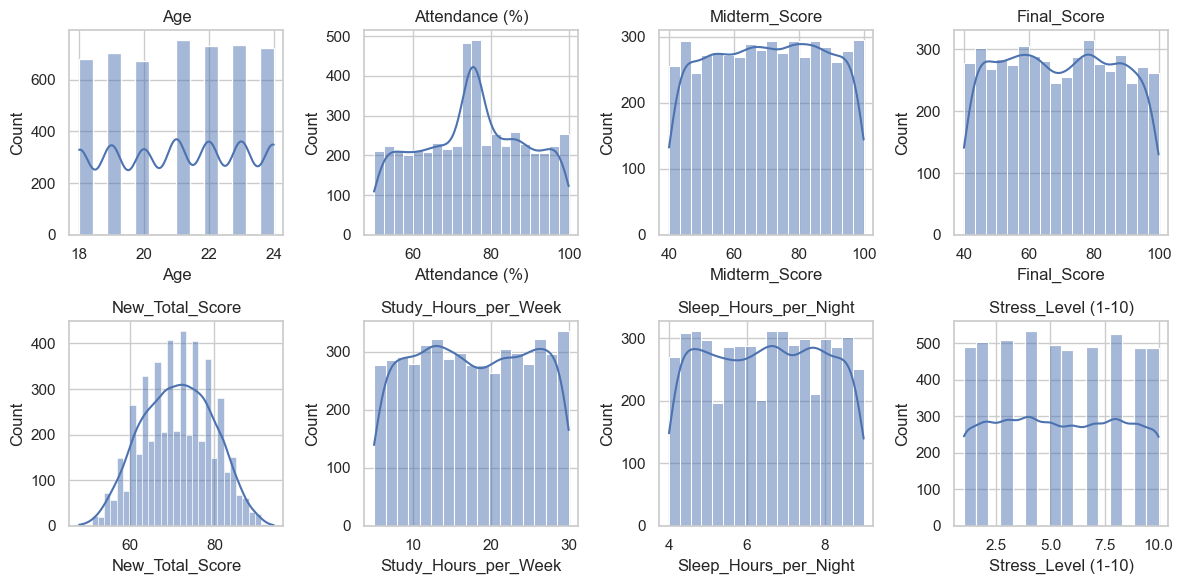

In [264]:
num_cols = ['Age', 'Attendance (%)', 'Midterm_Score', 'Final_Score', 'New_Total_Score', 
            'Study_Hours_per_Week', 'Sleep_Hours_per_Night', 'Stress_Level (1-10)']

plt.figure(figsize=(12, 6))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 4, i)
    sns.histplot(data_clean[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

grade distribution

C:\Users\DELL\AppData\Local\Temp\ipykernel_19004\4178975347.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data_clean['Letter_Grade'], order=data_clean['Letter_Grade'].value_counts().index, palette="coolwarm")


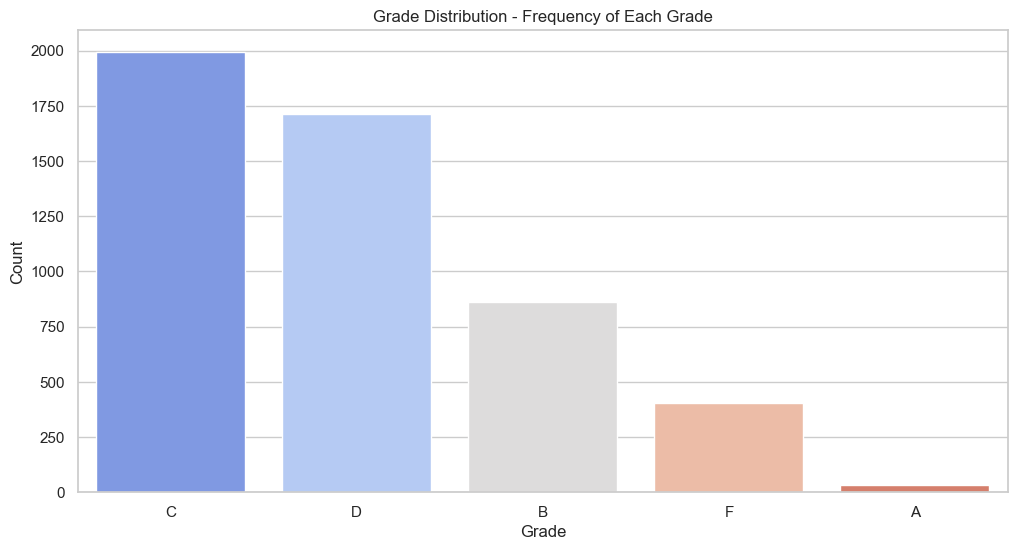

In [265]:
plt.figure(figsize=(12, 6))
sns.countplot(x=data_clean['Letter_Grade'], order=data_clean['Letter_Grade'].value_counts().index, palette="coolwarm")
plt.title("Grade Distribution - Frequency of Each Grade")
plt.xlabel("Grade")
plt.ylabel("Count")
plt.show()

distrbution of department by Grade

<Figure size 1000x500 with 0 Axes>

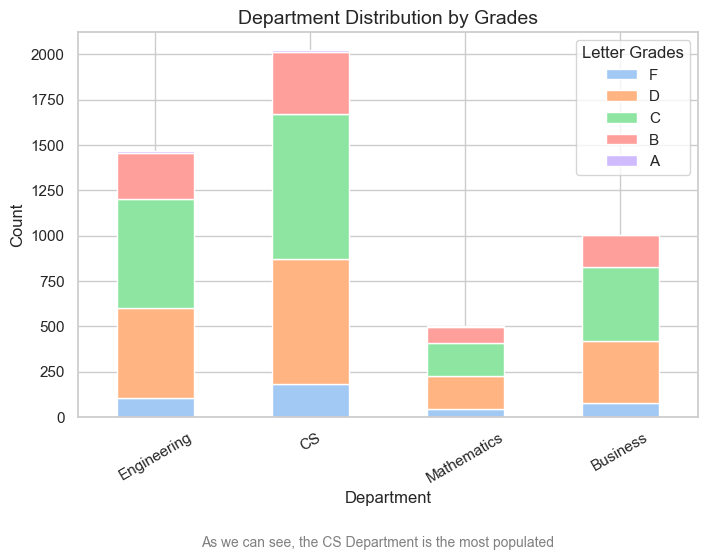

In [266]:

sns.set_theme(style='whitegrid')

# Count Department Distribution with Letter Grades and sort departments by 'A' grade count
dept_counts = pd.crosstab(data_clean['Department'], data_clean['Letter_Grade'])
dept_counts = dept_counts.sort_values(by='A', ascending=False)  # Sort rows by 'A' grade count
dept_counts = dept_counts[sorted(dept_counts.columns, reverse=True)]  # Sort columns from highest to lowest grade

# Define colors
bar_colors = sns.color_palette("pastel")

# Create figure
plt.figure(figsize=(10, 5))
dept_counts.plot(kind="bar", stacked=True, color=bar_colors, figsize=(8, 5))

# Add labels and title
plt.title("Department Distribution by Grades", fontsize=14)
plt.xlabel("Department", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.xticks(rotation=30)
plt.legend(title="Letter Grades")

plt.figtext(0.5, -0.15, "As we can see, the CS Department is the most populated",
            ha="center", fontsize=10, color="gray")

plt.show()


distribution of gender by grade

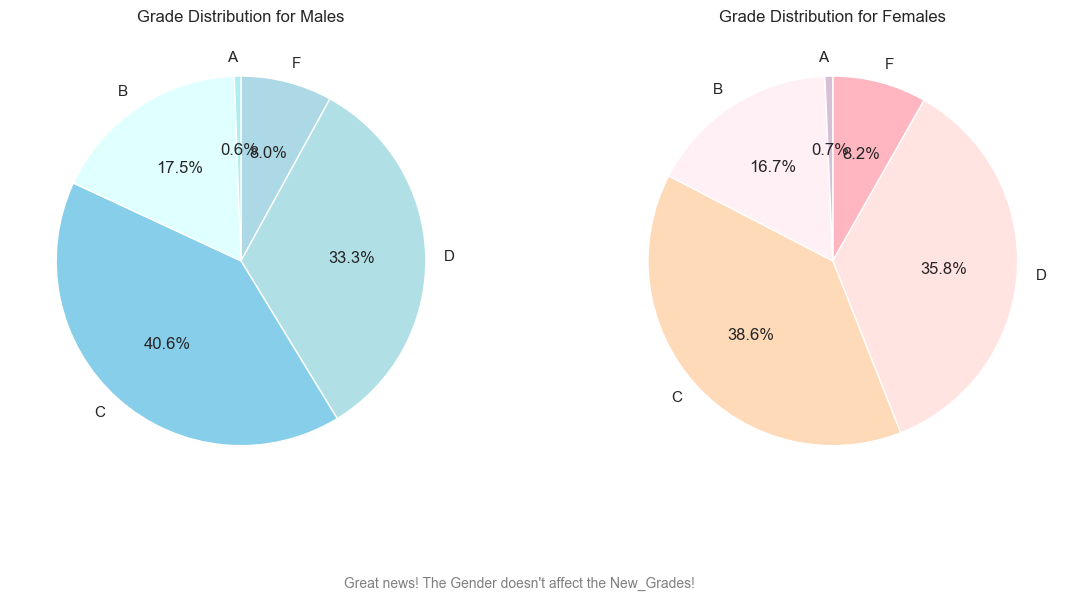

In [267]:
# Sort values in descending order for better visualization
male_New_Grade_counts = data_clean[data_clean['Gender_Male'] == True]['Letter_Grade'].value_counts().sort_index(ascending=False)
female_New_Grade_counts = data_clean[data_clean['Gender_Male'] == False]['Letter_Grade'].value_counts().sort_index(ascending=False)

# Define colors
male_colors = ['lightblue', 'powderblue', 'skyblue', 'lightcyan', 'paleturquoise']
female_colors = ['lightpink', 'mistyrose', 'peachpuff', 'lavenderblush', 'thistle']

# Create figure
plt.figure(figsize=(14, 6))

# Male Pie Chart
plt.subplot(1, 2, 1)
plt.pie(male_New_Grade_counts, labels=male_New_Grade_counts.index, autopct='%1.1f%%', 
        colors=male_colors, startangle=90, counterclock=False)
plt.title("Grade Distribution for Males")

# Female Pie Chart
plt.subplot(1, 2, 2)
plt.pie(female_New_Grade_counts, labels=female_New_Grade_counts.index, autopct='%1.1f%%', 
        colors=female_colors, startangle=90, counterclock=False)
plt.title("Grade Distribution for Females")

# Add Insight Text
plt.figtext(0.5, -0.05, "Great news! The Gender doesn't affect the New_Grades!",
            ha="center", fontsize=10, color="gray")

# Show plot
plt.show()


Relation of Midterm score and grade students level

C:\Users\DELL\AppData\Local\Temp\ipykernel_19004\2190195539.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=data_clean["Letter_Grade"], y=data_clean["Midterm_Score"], palette="Set2")


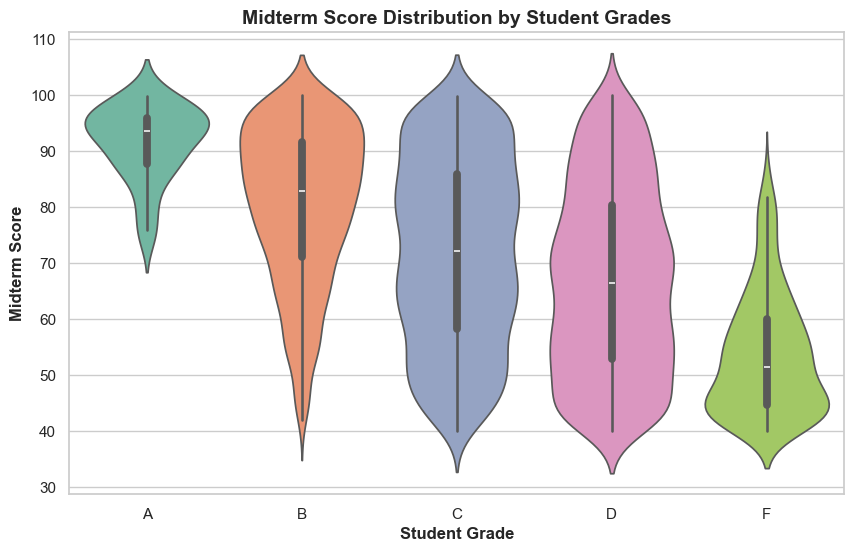

In [268]:
plt.figure(figsize=(10, 6))
sns.violinplot(x=data_clean["Letter_Grade"], y=data_clean["Midterm_Score"], palette="Set2")
plt.title("Midterm Score Distribution by Student Grades", fontsize=14, fontweight='bold')
plt.xlabel("Student Grade", fontsize=12, fontweight='bold')
plt.ylabel("Midterm Score", fontsize=12, fontweight='bold')

plt.show()


Total score distribution


C:\Users\DELL\AppData\Local\Temp\ipykernel_19004\381601743.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_clean['New_Grade'], y=data_clean['New_Total_Score'], palette="coolwarm",order=data_clean['New_Grade'].value_counts().index)


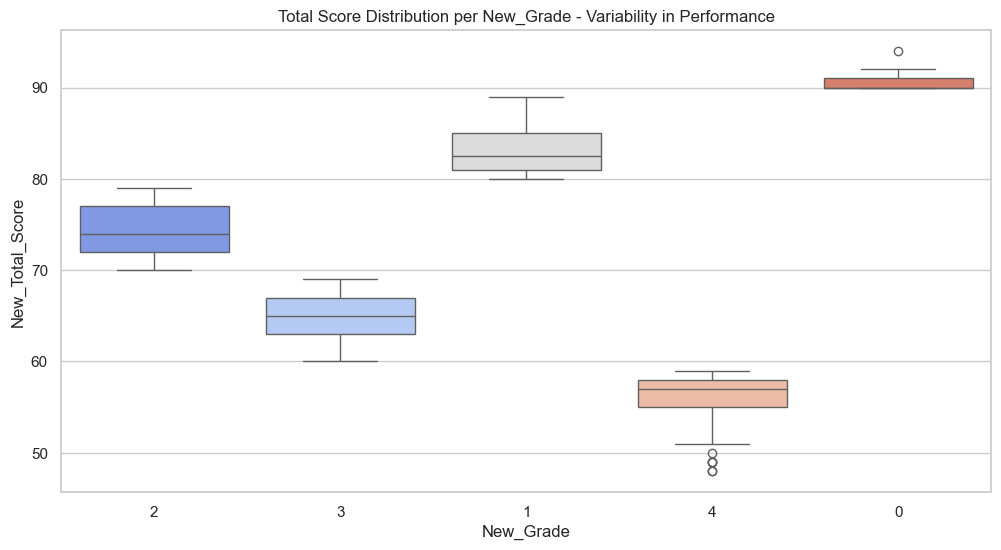

In [269]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=data_clean['New_Grade'], y=data_clean['New_Total_Score'], palette="coolwarm",order=data_clean['New_Grade'].value_counts().index)
plt.title("Total Score Distribution per New_Grade - Variability in Performance")
plt.show()

Show the gender percentile

C:\Users\DELL\AppData\Local\Temp\ipykernel_19004\222036123.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


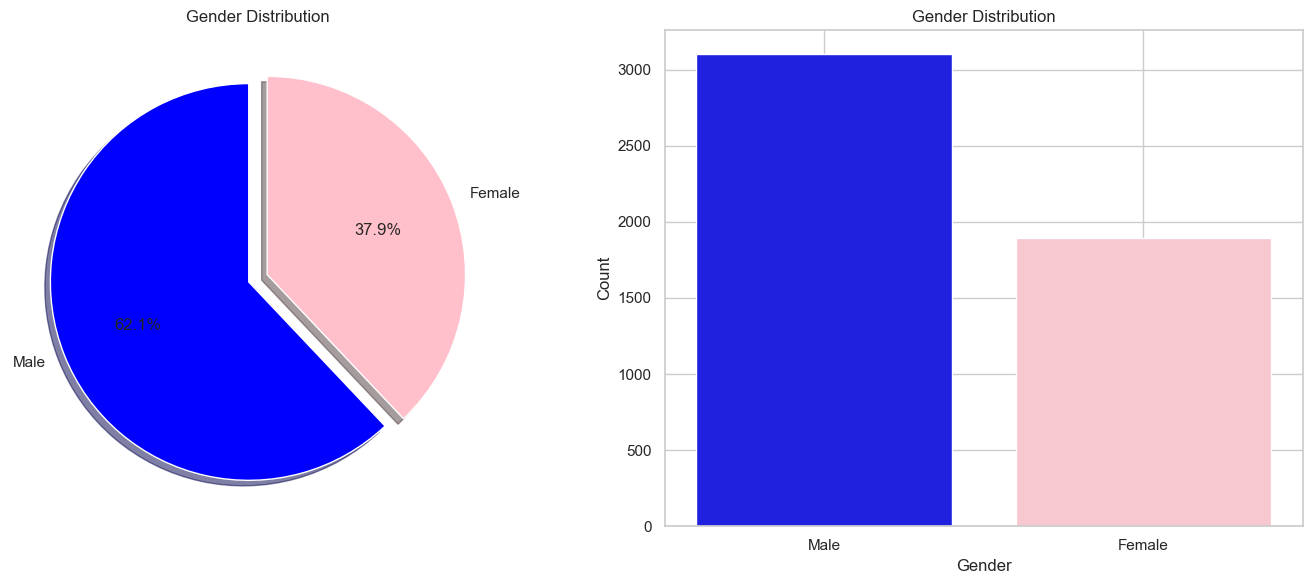

In [270]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Define custom labels
gender_labels = {True: "Male", False: "Female"}

# PIE CHART
gender_counts = data_clean['Gender_Male'].value_counts().sort_values(ascending=False)
axes[0].pie(
    gender_counts, 
    labels=[gender_labels[label] for label in gender_counts.index],  # Convert True/False to Male/Female
    autopct="%.1f%%", shadow=True, colors=["blue", "pink"],
    startangle=90, explode=[0.05, 0.05]
)
axes[0].set_title("Gender Distribution")

# BAR CHART
sns.barplot(
    x=[gender_labels[label] for label in gender_counts.index],  # Convert True/False to Male/Female
    y=gender_counts.values,
    ax=axes[1], palette=["blue", "pink"]
)
axes[1].set_title("Gender Distribution")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Count")
axes[1].grid(True)

plt.tight_layout()
plt.show()


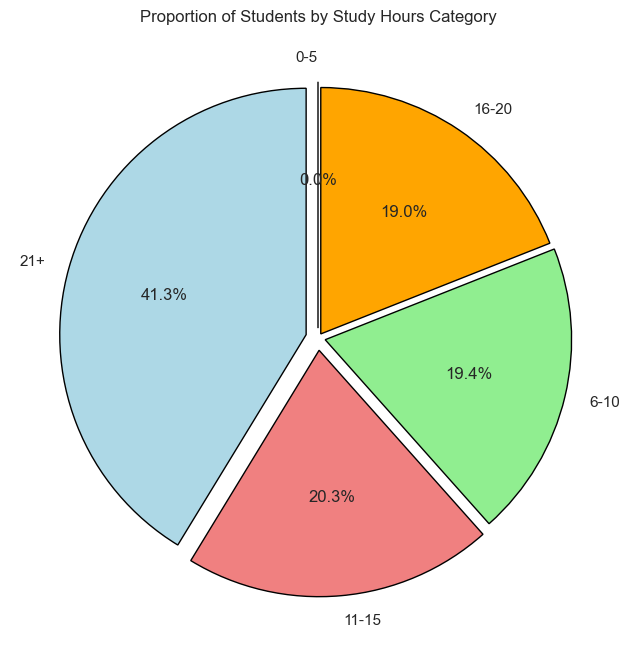

In [271]:
# Grouping students based on study hours per week
data_clean["Study_Category"] = pd.cut(data_clean["Study_Hours_per_Week"], 
                              bins=[0, 5, 10, 15, 20, np.inf], 
                              labels=["0-5", "6-10", "11-15", "16-20", "21+"],
                              include_lowest=True, right=False
                              
                              )
# Count the number of students in each category
study_counts = data_clean["Study_Category"].value_counts().sort_values(ascending=False)

# Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(study_counts, labels=study_counts.index, autopct="%1.1f%%", 
        colors=["lightblue", "lightcoral", "lightgreen", "orange", "purple"], 
        startangle=90, wedgeprops={'edgecolor': 'black'},
        explode=[0.05, 0.05,0.03,0.02,0.04]
        )

plt.title("Proportion of Students by Study Hours Category")
plt.show()


show the relations between columns

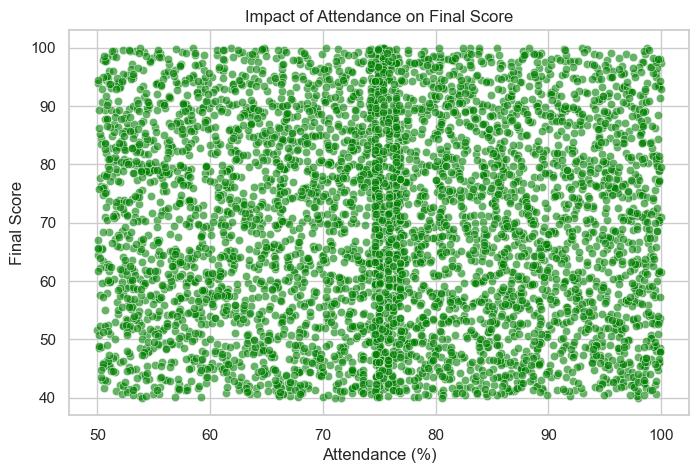

In [272]:
# Scatter plot: Attendance vs. Final Score
plt.figure(figsize=(8,5))
sns.scatterplot(x=data_clean["Attendance (%)"], y=data_clean["Final_Score"], color="green", alpha=0.6)
plt.title("Impact of Attendance on Final Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Final Score")
plt.show()
#Reveals if students with high attendance tend to score better

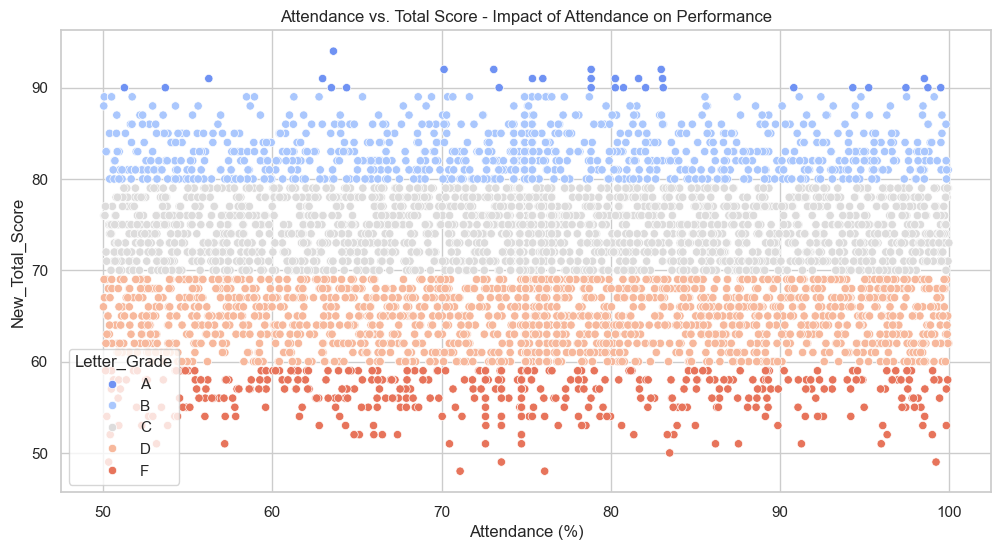

In [273]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x=data_clean["Attendance (%)"], y=data_clean['New_Total_Score'], hue=data_clean['Letter_Grade'], palette="coolwarm")
plt.title("Attendance vs. Total Score - Impact of Attendance on Performance")
plt.show()

show the  Relationship Between Study Time and Scores")


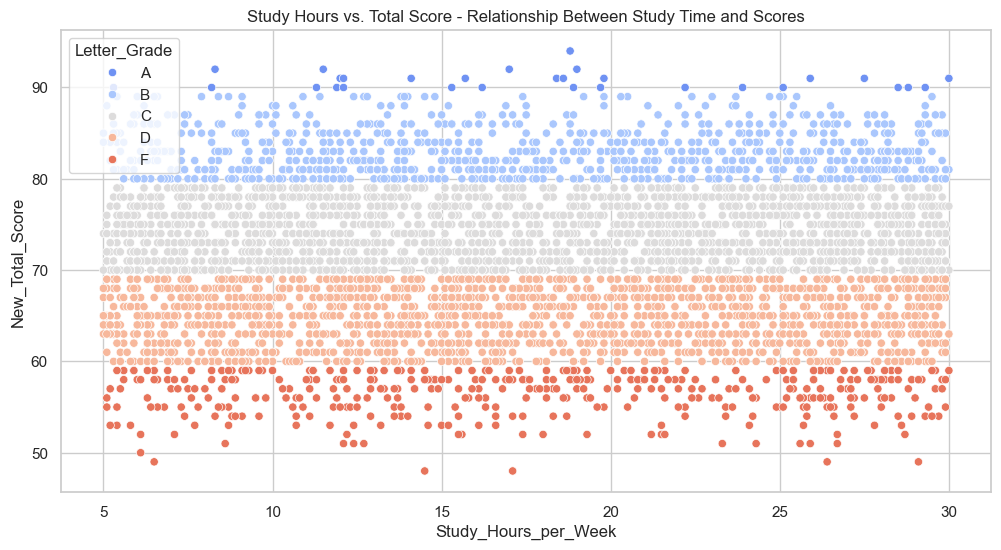

In [274]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x=data_clean['Study_Hours_per_Week'], y=data_clean['New_Total_Score'], hue=data_clean['Letter_Grade'], palette="coolwarm")  
plt.title("Study Hours vs. Total Score - Relationship Between Study Time and Scores")
plt.show()


Lineplot
Uses line plots to show how stress levels and sleep hours change with age.
Helps see trends

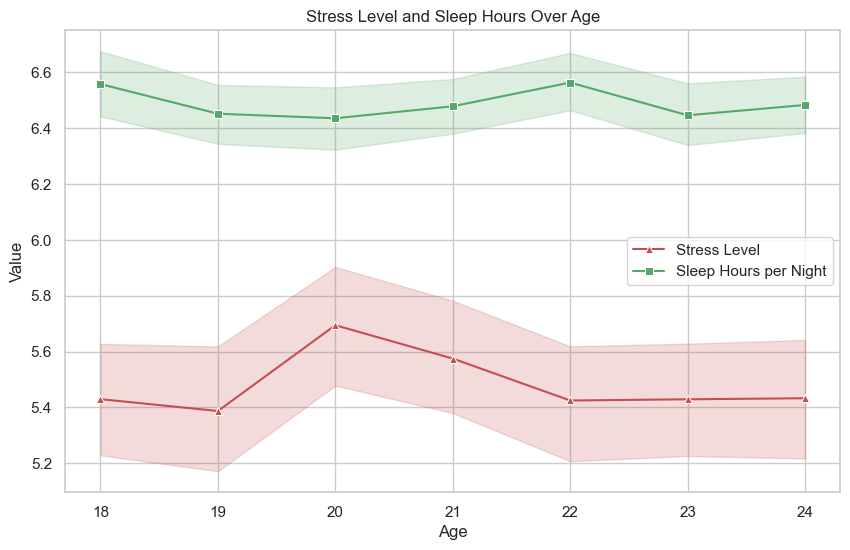

In [275]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=data_clean['Age'], y=data_clean['Stress_Level (1-10)'], label="Stress Level", marker='^', color='r')
sns.lineplot(x=data_clean['Age'], y=data_clean['Sleep_Hours_per_Night'], label="Sleep Hours per Night", marker='s', color='g')
plt.xlabel("Age")
plt.ylabel("Value")
plt.title("Stress Level and Sleep Hours Over Age")
plt.legend()
plt.show()

show the count of student based on stress level 

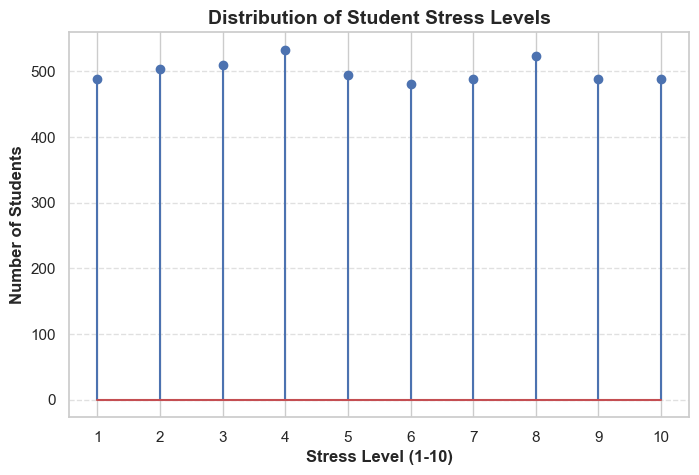

In [276]:
ordered_data_clean = data_clean['Stress_Level (1-10)'].value_counts().sort_index()

# Create stem plot
plt.figure(figsize=(8, 5))
plt.stem(ordered_data_clean.index, ordered_data_clean.values, linefmt='b-', markerfmt='bo', basefmt='r-')

# Formatting
plt.xticks(ordered_data_clean.index)  # Set x-axis ticks to stress levels
plt.xlabel("Stress Level (1-10)", fontsize=12, fontweight='bold')
plt.ylabel("Number of Students", fontsize=12, fontweight='bold')
plt.title("Distribution of Student Stress Levels", fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle="--", alpha=0.6)

# Show plot
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_19004\3836681102.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Stress_Level (1-10)', y='New_Total_Score', data=data_clean, palette="coolwarm")


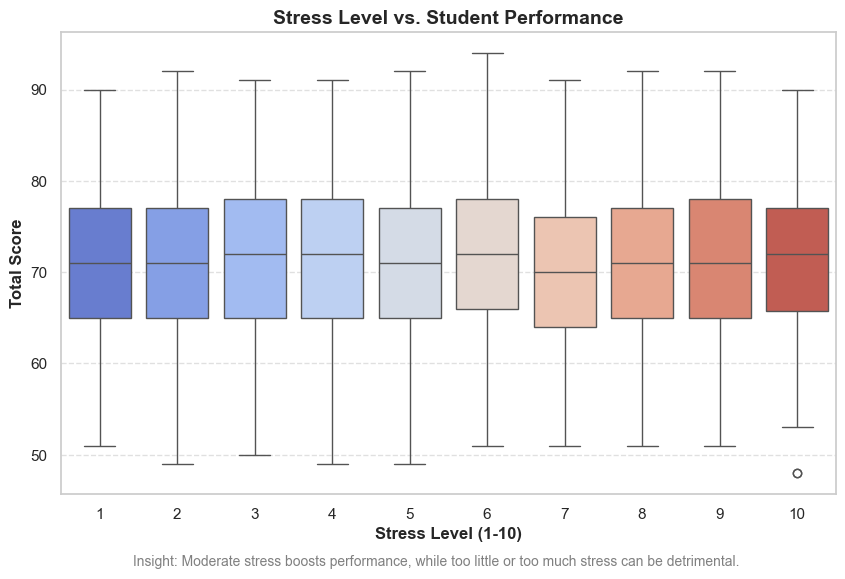

In [277]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Stress_Level (1-10)', y='New_Total_Score', data=data_clean, palette="coolwarm")

# Formatting
plt.xlabel("Stress Level (1-10)", fontsize=12, fontweight='bold')
plt.ylabel("Total Score", fontsize=12, fontweight='bold')
plt.title("Stress Level vs. Student Performance", fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle="--", alpha=0.6)
plt.figtext(0.5, -0.01,
            "Insight: Moderate stress boosts performance, while too little or too much stress can be detrimental.",
            ha="center", fontsize=10, color="gray")

# Show plot
plt.show()

relaiton between stress level and final score

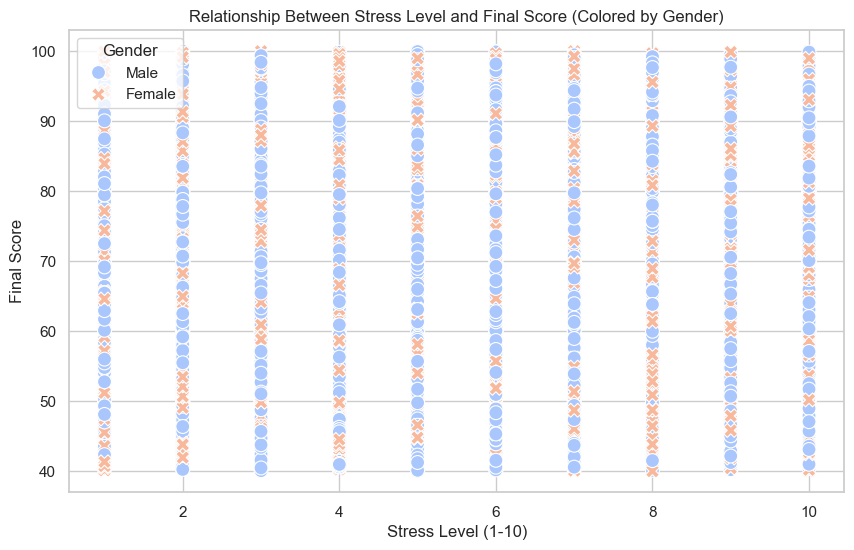

In [278]:
plt.figure(figsize=(10, 6))

# Define custom labels for legend
gender_labels = {True: "Male", False: "Female"}
# Scatter plot for Stress Level vs. Final Score with gender as hue
scatter = sns.scatterplot(
    x=data_clean["Stress_Level (1-10)"], 
    y=data_clean["Final_Score"], 
    hue=data_clean["Gender_Male"].map(gender_labels),  # Convert True/False to Male/Female
    style=data_clean["Gender_Male"].map(gender_labels), 
    palette="coolwarm", s=100
)
plt.xlabel("Stress Level (1-10)")
plt.ylabel("Final Score")
plt.title("Relationship Between Stress Level and Final Score (Colored by Gender)")
plt.legend(title="Gender", loc="upper left")
plt.show()


 KDE (Kernel Density Estimation) plot to visualize the distribution of Final Scores and compare it across different features:
 

C:\Users\DELL\AppData\Local\Temp\ipykernel_19004\2274292654.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data_clean["Final_Score"], shade=True, color="blue")


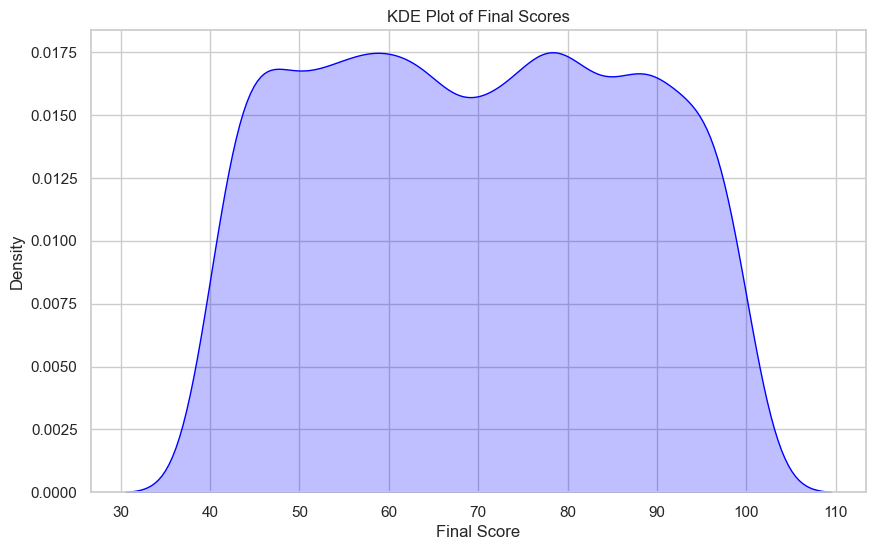

In [279]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data_clean["Final_Score"], shade=True, color="blue")
plt.title("KDE Plot of Final Scores")
plt.xlabel("Final Score")
plt.ylabel("Density")
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_19004\982950775.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Study Hours per Week")


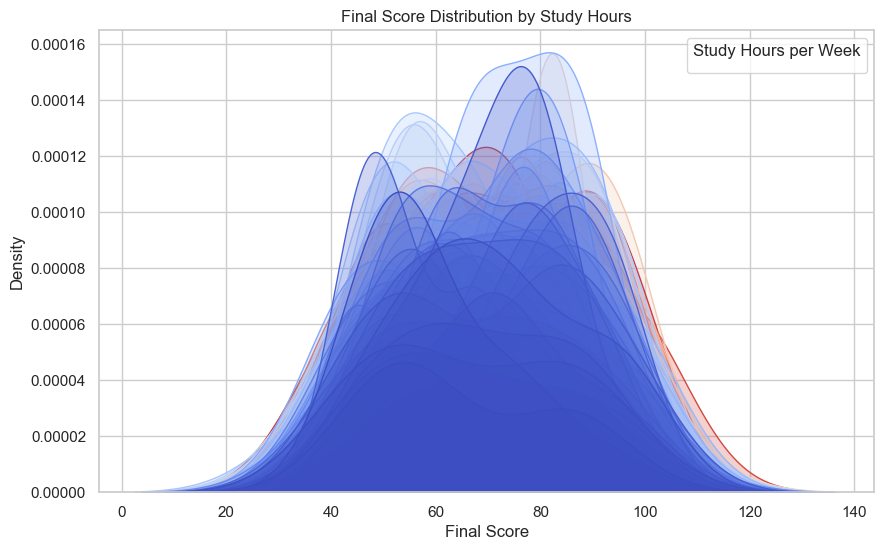

In [280]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=data_clean, x="Final_Score", hue="Study_Hours_per_Week", fill=True, palette="coolwarm")
plt.title("Final Score Distribution by Study Hours")
plt.xlabel("Final Score")
plt.ylabel("Density")
plt.legend(title="Study Hours per Week")
plt.show()

bar char to show the average final score by study hours category

C:\Users\DELL\AppData\Local\Temp\ipykernel_19004\3738883524.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data_clean["Study_Category"], y=data_clean["Final_Score"], palette="viridis")


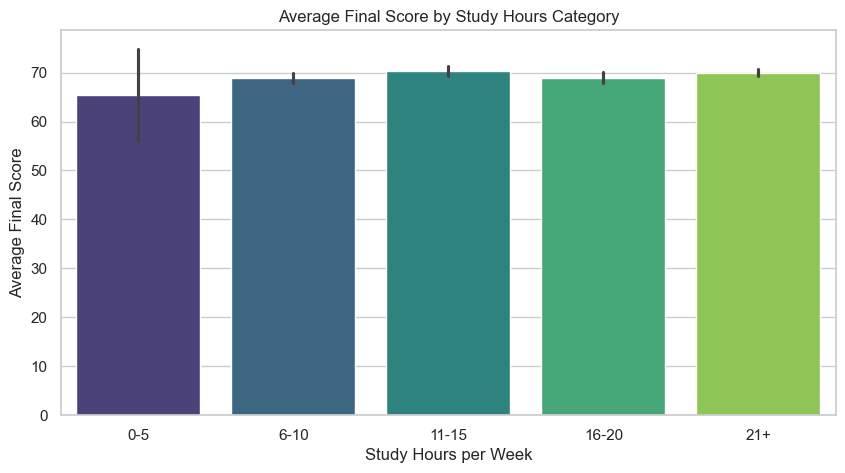

In [281]:
# Bar Chart - Average Scores by Study Hours Category**
data_clean["Study_Category"] = pd.cut(data_clean["Study_Hours_per_Week"], bins=[0, 5, 10, 15, 20, np.inf], labels=["0-5", "6-10", "11-15", "16-20", "21+"])
plt.figure(figsize=(10, 5))
sns.barplot(x=data_clean["Study_Category"], y=data_clean["Final_Score"], palette="viridis")
plt.title("Average Final Score by Study Hours Category")
plt.xlabel("Study Hours per Week")
plt.ylabel("Average Final Score")
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_19004\1345538613.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Letter_Grade", y="Sleep_Hours_per_Night", data=data_clean, palette="pastel")


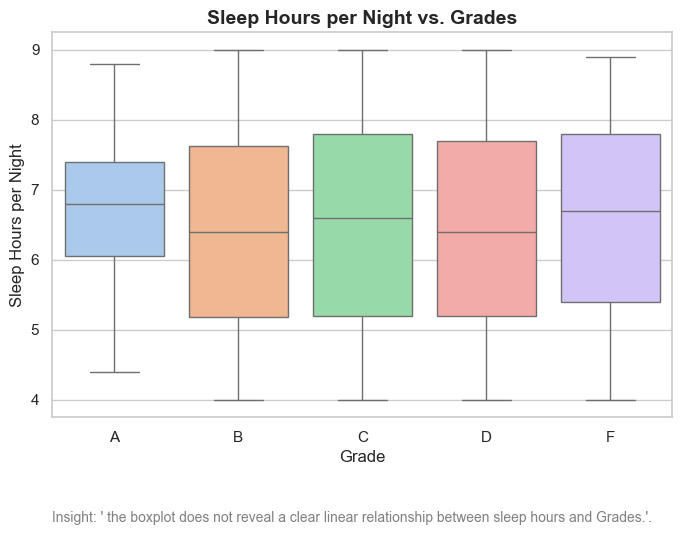

In [282]:
sns.set_theme(style="whitegrid")

# Create the boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x="Letter_Grade", y="Sleep_Hours_per_Night", data=data_clean, palette="pastel")

# Add title and axis labels
plt.title("Sleep Hours per Night vs. Grades", fontsize=14, fontweight='bold')
plt.xlabel("Grade", fontsize=12)
plt.ylabel("Sleep Hours per Night", fontsize=12)
plt.figtext(0.5, -0.1,
            "Insight: ' the boxplot does not reveal a clear linear relationship between sleep hours and Grades.'.",
            ha="center", fontsize=10, color="gray")

plt.show()

distribution of family income level

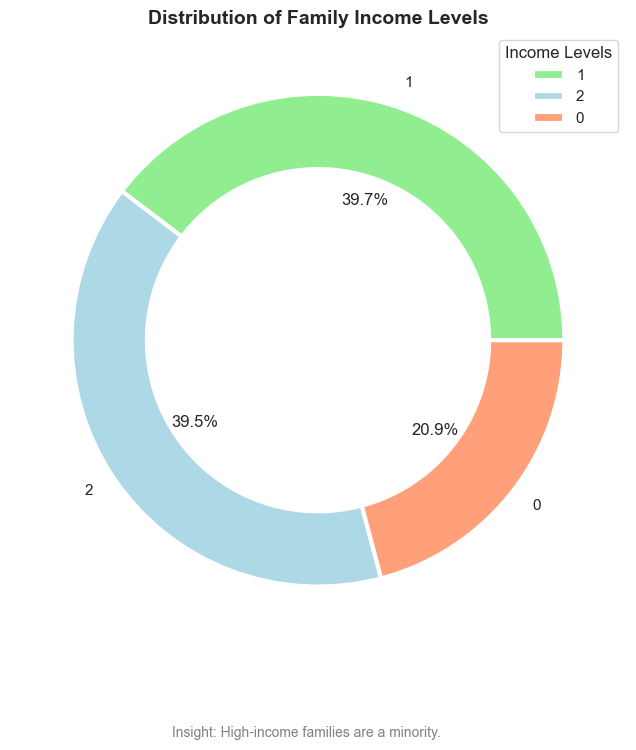

In [283]:
plt.figure(figsize=(8, 8))

# Create a white circle in the center for a donut effect
my_circle = plt.Circle((0, 0), 0.7, color='white')

# Get value counts for Family_Income_Level
income_counts = data_clean['Family_Income_Level'].value_counts()

# Create a donut pie chart
plt.pie(income_counts,
        labels=income_counts.index,  # Ensure correct labels
        colors=['lightgreen', 'lightblue', 'lightsalmon'],  # Valid colors
        autopct='%1.1f%%',
        wedgeprops={'linewidth': 3, 'edgecolor': 'white'})  # Adjust edge thickness

# Add the white circle to make it a donut chart
p = plt.gcf()
p.gca().add_artist(my_circle)

# Add a legend and title
plt.legend(title="Income Levels")
plt.title("Distribution of Family Income Levels", fontsize=14, fontweight='bold')
plt.figtext(0.5, -0.001,
            "Insight: High-income families are a minority. ",
            ha="center", fontsize=10, color="gray")

# Show the graph
plt.show()

Family income and the Grade

C:\Users\DELL\AppData\Local\Temp\ipykernel_19004\1181987253.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_New_Grade_counts = data_clean.groupby(["Family_Income_Level_Named", "Letter_Grade"]).size().unstack()


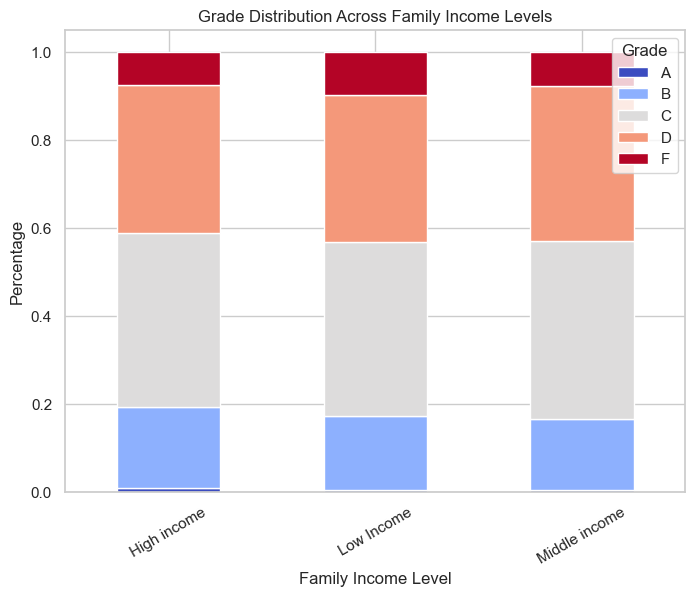

In [284]:
# Define custom labels for income levels
income_labels = {
    0:"Low Income",
    1: "Middle income",
    2: "High income",
}

# Apply mapping to rename Family_Income_Level
data_clean["Family_Income_Level_Named"] = data_clean["Family_Income_Level"].map(income_labels)

# Recalculate income_New_Grade_counts with updated names
income_New_Grade_counts = data_clean.groupby(["Family_Income_Level_Named", "Letter_Grade"]).size().unstack()

# Normalize values to percentages
income_New_Grade_counts = income_New_Grade_counts.div(income_New_Grade_counts.sum(axis=1), axis=0)

# Plot stacked bar chart
income_New_Grade_counts.plot(kind="bar", stacked=True, figsize=(8, 6), colormap="coolwarm")
plt.xlabel("Family Income Level")
plt.ylabel("Percentage")
plt.title("Grade Distribution Across Family Income Levels")
plt.legend(title="Grade")
plt.xticks(rotation=30)  # Rotate labels for better readability
plt.show()


 show Low attendance is strongly correlated with low grades

<Figure size 1000x600 with 0 Axes>

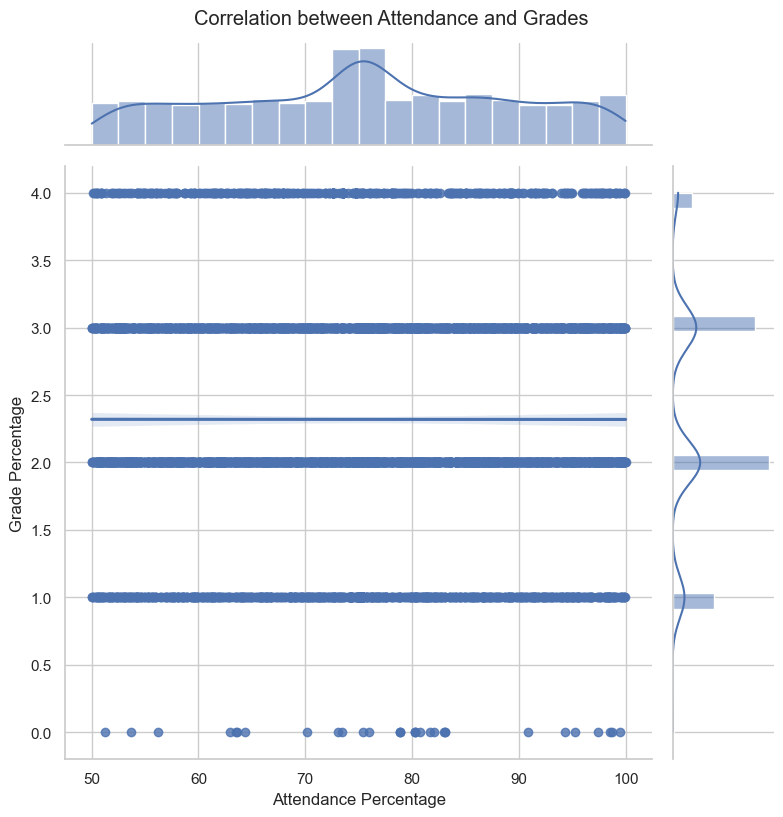

In [285]:
# Joint plot with regression line
plt.figure(figsize=(10, 6))
sns.jointplot(x='Attendance (%)', y='New_Grade', data=data_clean, kind='reg', height=8, ratio=5, color='b')

plt.xlabel("Attendance Percentage")
plt.ylabel("Grade Percentage")
plt.suptitle("Correlation between Attendance and Grades", y=1.02)
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_19004\463962758.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Letter_Grade", y="Attendance (%)", data=data_clean, palette="Set3")


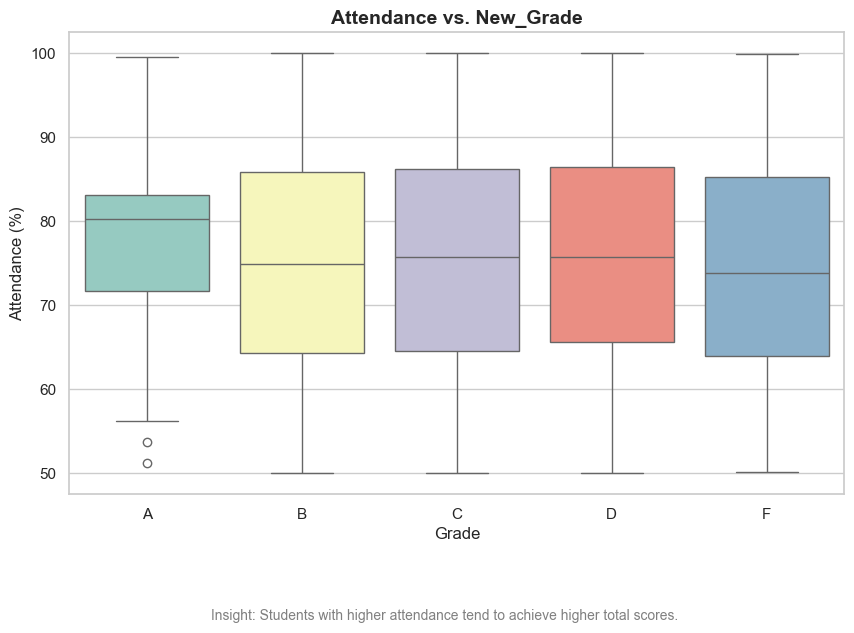

In [286]:
sns.set_theme(style="whitegrid")

# Create the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Letter_Grade", y="Attendance (%)", data=data_clean, palette="Set3")

# Add title and labels
plt.title("Attendance vs. New_Grade", fontsize=14, fontweight='bold')
plt.xlabel("Grade", fontsize=12)
plt.ylabel("Attendance (%)", fontsize=12)
plt.figtext(0.5, -0.1,
            "Insight: Students with higher attendance tend to achieve higher total scores.",
            ha="center", fontsize=10, color="gray")

plt.show()

internet accsess at home 

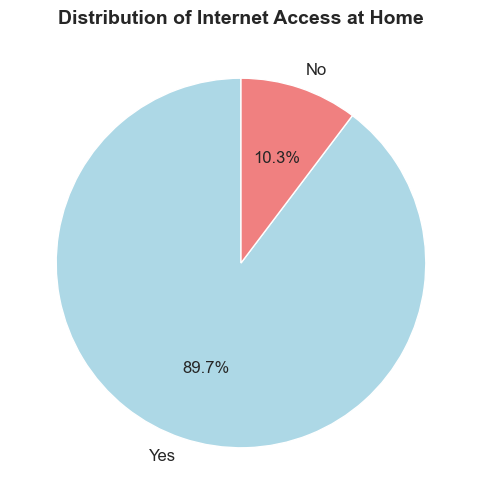

In [287]:
internet_counts = data_clean["Internet_Access_at_Home_Yes"].value_counts()
acssec={
    False:"No",
    True:"Yes"
}

# Define colors
colors = ["lightblue", "lightcoral"]

# Create pie chart
plt.figure(figsize=(6, 6))
plt.pie(internet_counts, labels=internet_counts.index.map(acssec), autopct='%1.1f%%', colors=colors,
         startangle=90, textprops={'fontsize': 12})

# Add title
plt.title("Distribution of Internet Access at Home", fontsize=14, fontweight="bold")

# Show plot
plt.show()

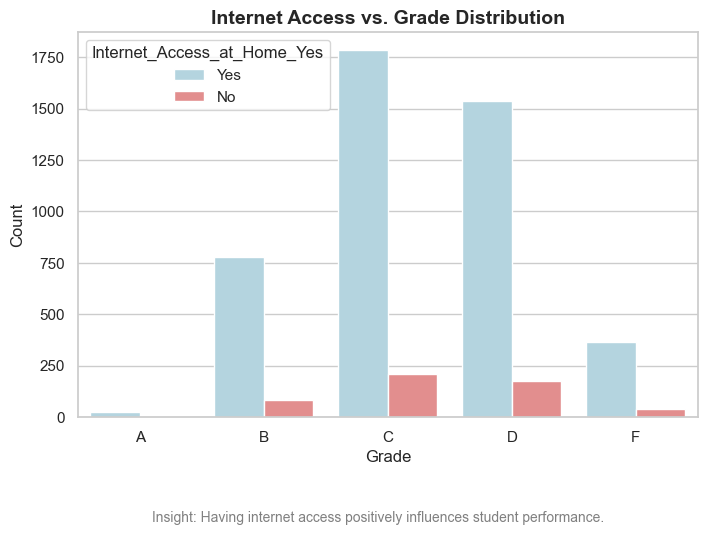

In [288]:
# Rename True/False values
data_clean["Internet_Access_at_Home_Yes"] = data_clean["Internet_Access_at_Home_Yes"].replace({True: "Yes", False: "No"})

# Plot
plt.figure(figsize=(8, 5))

sns.countplot(x=data_clean["Letter_Grade"], hue=data_clean["Internet_Access_at_Home_Yes"], palette=["lightblue", "lightcoral"])

# Add title and labels
plt.title("Internet Access vs. Grade Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Grade", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.figtext(0.5, -0.1,
            "Insight: Having internet access positively influences student performance.",
            ha="center", fontsize=10, color="gray")

plt.show()


Extracurricular_Activities

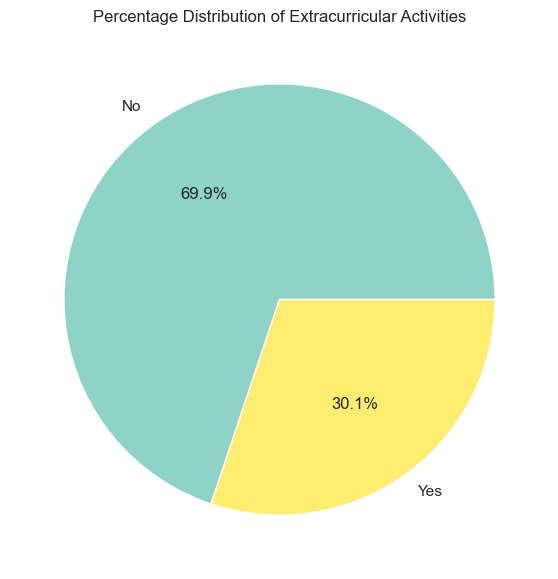

In [289]:
# Rename True/False values
data_clean["Extracurricular_Activities_Yes"] = data_clean["Extracurricular_Activities_Yes"].replace({True: "Yes", False: "No"})
# Plot
data_clean["Extracurricular_Activities_Yes"].value_counts().plot(kind="pie", autopct="%1.1f%%", figsize=(7, 7), colormap="Set3")

plt.ylabel("")  # Hide y-label for better visualization
plt.title("Percentage Distribution of Extracurricular Activities")

plt.show()


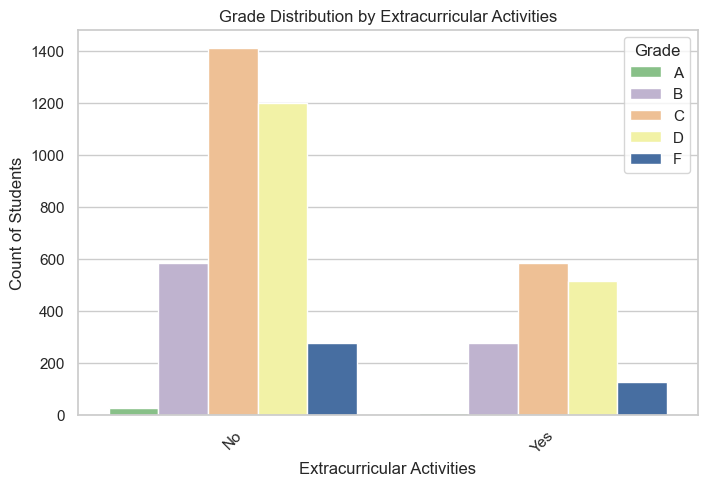

In [290]:
plt.figure(figsize=(8, 5))
# Rename True/False values
data_clean["Extracurricular_Activities_Yes"] = data_clean["Extracurricular_Activities_Yes"].replace({True: "Yes", False: "No"})

sns.countplot(x=data_clean["Extracurricular_Activities_Yes"], hue=data_clean["Letter_Grade"],palette="Accent")
plt.xlabel("Extracurricular Activities")
plt.ylabel("Count of Students")
plt.title("Grade Distribution by Extracurricular Activities")
plt.xticks(rotation=45)
plt.legend(title="Grade")
plt.show()

pairplot with features

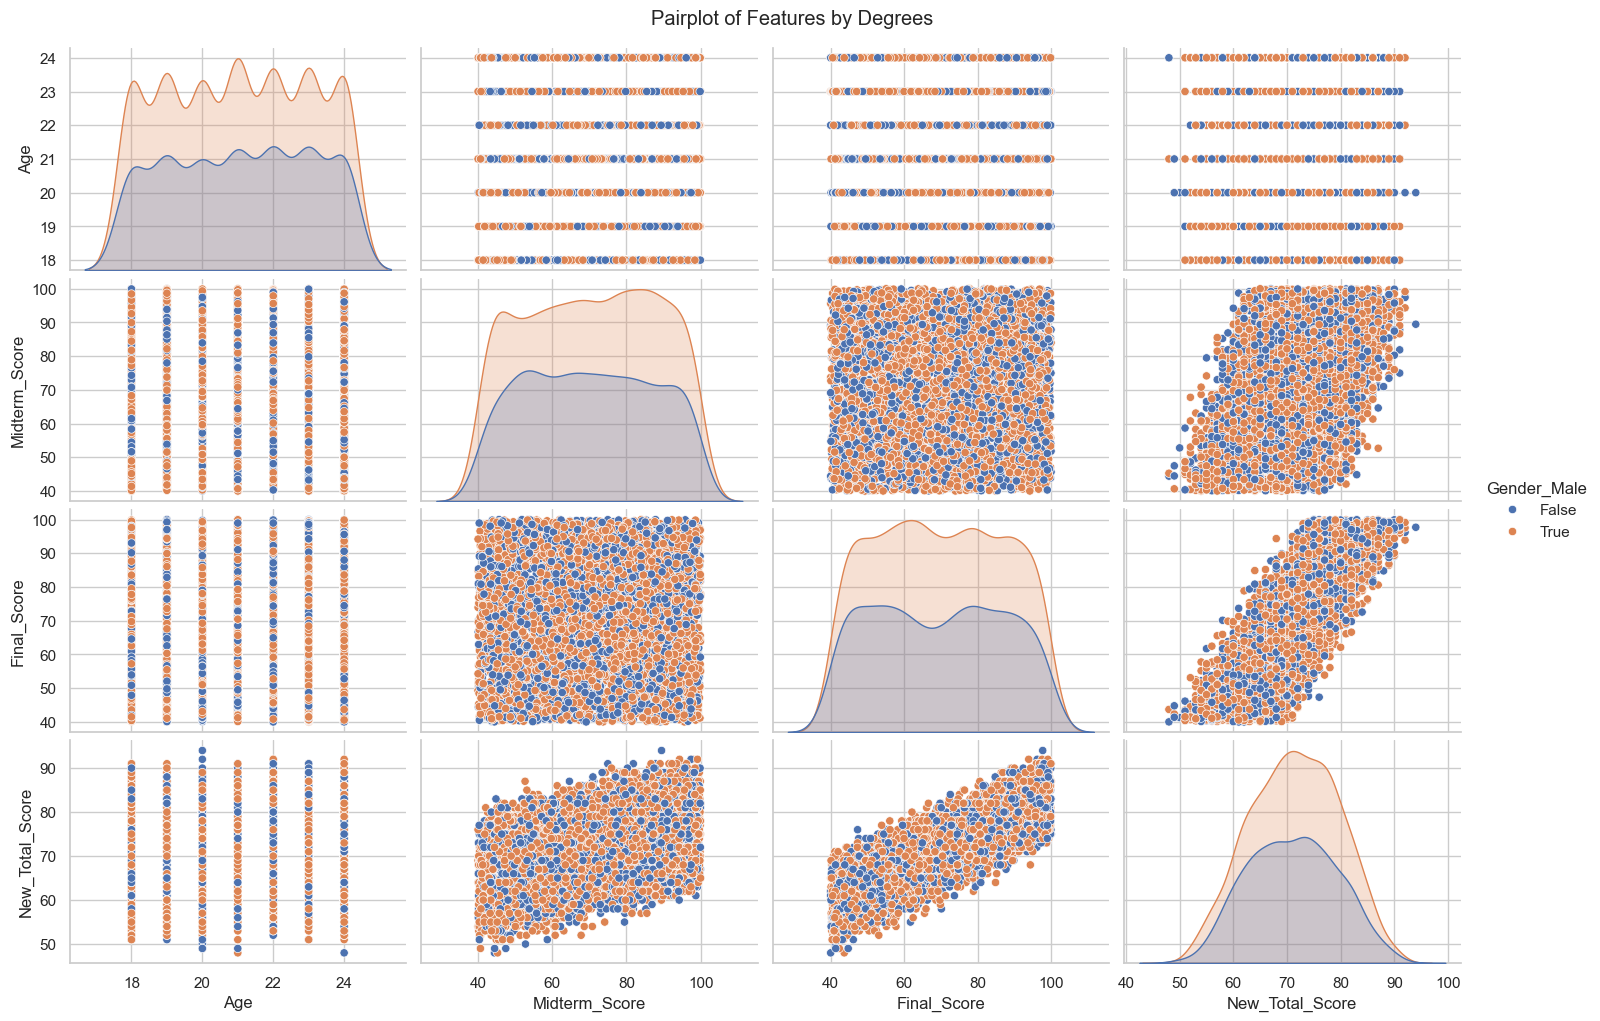

In [291]:
# Create a pairplot with enhanced aesthetics
sns.set(style="whitegrid")
pairplot = sns.pairplot(data_clean, hue='Gender_Male', vars=['Age', 'Midterm_Score', 'Final_Score', 'New_Total_Score'], height=2.5, aspect=1.5)
plt.suptitle('Pairplot of Features by Degrees', y=1.02)  
plt.show()

**Attendance vs. Final Score (Higher Attendance → Better Scores)**                                                                                     
📌 Hypothesis: Students with higher attendance have better final scores.

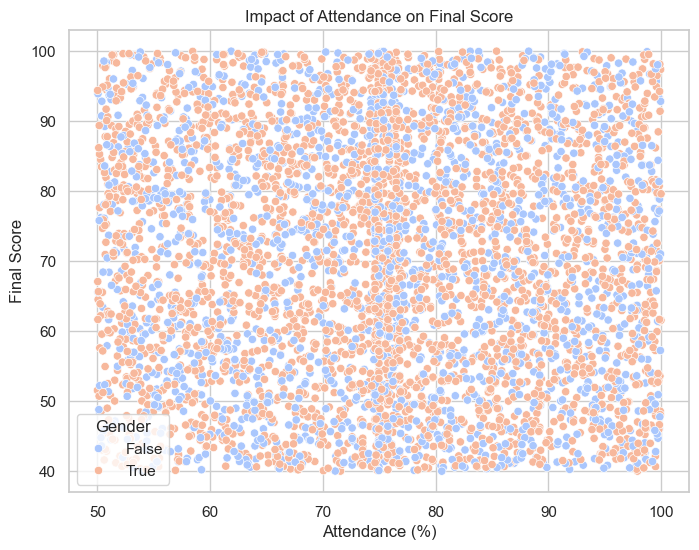

In [292]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data_clean["Attendance (%)"], y=data_clean["Final_Score"], hue=data_clean["Gender_Male"], palette="coolwarm")
plt.xlabel("Attendance (%)")
plt.ylabel("Final Score")
plt.title("Impact of Attendance on Final Score")
plt.legend(title="Gender")
plt.show()


**Study Hours vs. Final Score (More Study → Better Grades)**                                                                                     
📌 Hypothesis: More study hours per week lead to better grades.

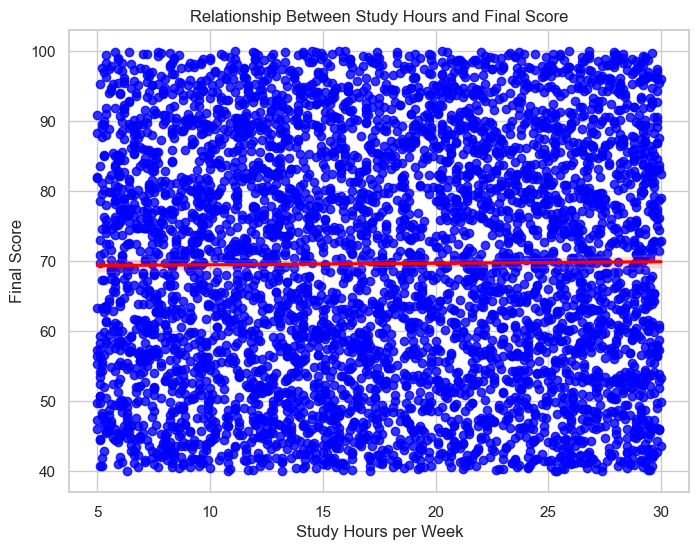

In [293]:
plt.figure(figsize=(8, 6))
sns.regplot(x=data_clean["Study_Hours_per_Week"], y=data_clean["Final_Score"], scatter_kws={"color": "blue"}, line_kws={"color": "red"})
plt.xlabel("Study Hours per Week")
plt.ylabel("Final Score")
plt.title("Relationship Between Study Hours and Final Score")
plt.show()


**Stress Level vs. Final Score (High Stress → Lower Scores)**                                                                                         

📌 Hypothesis: High-stress students tend to score lower.

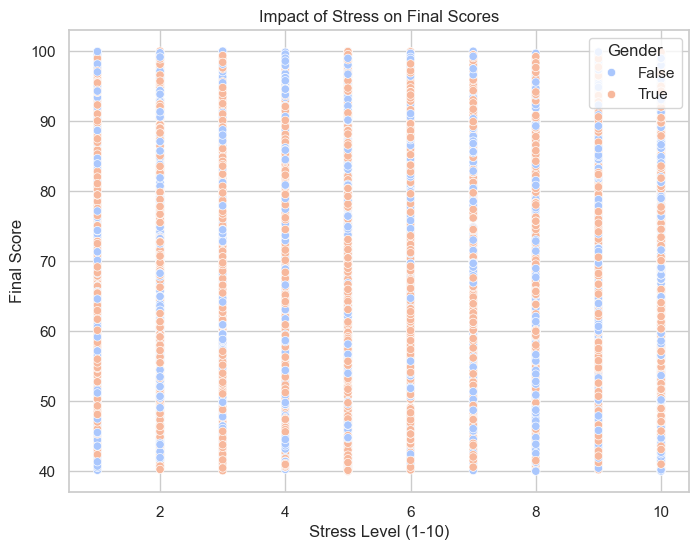

In [294]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data_clean["Stress_Level (1-10)"], y=data_clean["Final_Score"], hue=data_clean["Gender_Male"], palette="coolwarm")
plt.xlabel("Stress Level (1-10)")
plt.ylabel("Final Score")
plt.title("Impact of Stress on Final Scores")
plt.legend(title="Gender")
plt.show()


 **Poor Sleep & High Stress → Negative Impact on Grades**                                                                                            
📌 Hypothesis: Less sleep & high stress lead to lower scores.

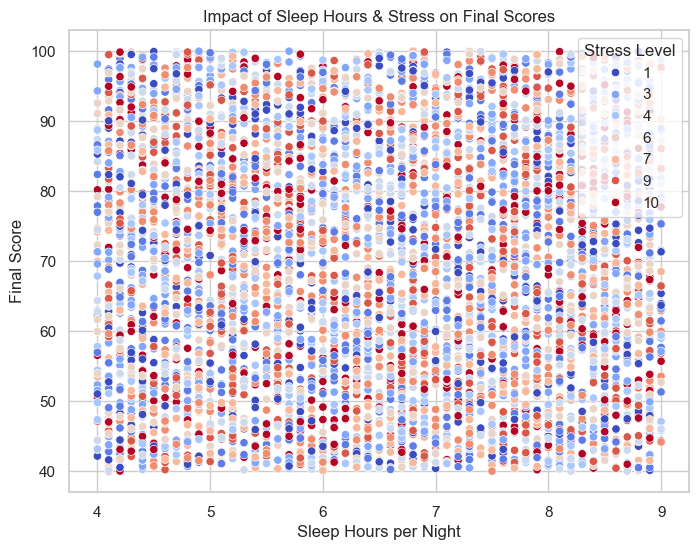

In [295]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data_clean["Sleep_Hours_per_Night"], y=data_clean["Final_Score"], hue=data_clean["Stress_Level (1-10)"], palette="coolwarm")
plt.xlabel("Sleep Hours per Night")
plt.ylabel("Final Score")
plt.title("Impact of Sleep Hours & Stress on Final Scores")
plt.legend(title="Stress Level")
plt.show()


# ML & DL Models Evaluation

 **Hypothesis Testing: Does High Stress Affect Scores?**                                                                                        
To statistically test whether high stress affects final scores, we use a T-test.

Group 1: Low-stress students (Stress_Level <= 5)  or <= median                                                                                                      
Group 2: High-stress students (Stress_Level > 5) or > median

In [296]:
# Calculate correlation
corr_stress_score = data_clean["Stress_Level (1-10)"].corr(data_clean["Final_Score"])
print(f"Correlation between Stress Level and Final Score: {corr_stress_score:.2f}")

# T-test: High vs. Low Stress Impact
low_stress = data_clean[data_clean["Stress_Level (1-10)"] <= 5]["Final_Score"]
high_stress = data_clean[data_clean["Stress_Level (1-10)"] > 5]["Final_Score"]

t_stat, p_value = ttest_ind(low_stress, high_stress, equal_var=False)
print(f"Tt-Statistic: {t_stat:.2f}")
print(f"Pp-Value: {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: High stress has a significant negative impact on final scores.")
else:
    print("Conclusion: No significant difference found between low and high-stress students.")


Correlation between Stress Level and Final Score: -0.00
Tt-Statistic: 0.48
Pp-Value: 0.6286
Conclusion: No significant difference found between low and high-stress students.


## **Models Evaluation**
**Steps for Building the Predictive Model**                                                                                                  
1️⃣ Select Features & Target Variable (Independent vs. Dependent)                                                                   
2️⃣ Handle Categorical Data (Encoding)                                                                                  
3️⃣ Split Data into Training & Testing Sets                                                                             
4️⃣ Train Machine Learning Models (Linear Regression, Decision Tree, Random Forest)                                                                   
5️⃣ Evaluate Model Performance (Accuracy, RMSE, R² Score)                                                                                    
6️⃣ Optimize the Model (Hyperparameter tuning if needed)                                                                

In [297]:
# Selecting relevant features
features = ["Attendance (%)", "Study_Hours_per_Week", "Stress_Level (1-10)", "Sleep_Hours_per_Night",
            "Assignments_Avg", "Quizzes_Avg", "Midterm_Score", "Projects_Score"]

target = "Final_Score" #  Target Variable: Final_Score

X = data_clean[features]
y = data_clean[target]


**Split Data into Training & Testing Sets**
We split the data 80% training, 20% testing for model evaluation.

In [298]:
# Splitting into train & test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Set: {X_train.shape}, Testing Set: {X_test.shape}")


Training Set: (4000, 8), Testing Set: (1000, 8)


## **Train Machine Learning Models**
We’ll try three models:                                                                                                             
✅ Linear Regression (Baseline)                                                                                                             
✅ Decision Tree (Handles non-linearity)                                                  
✅ Random Forest (Ensemble model for better accuracy)

In [299]:
# Train Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Train Decision Tree Model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Train Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Models trained successfully!")


Models trained successfully!


In [300]:
# Function to evaluate models
def evaluate_model(model, name):
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{name} Model Performance:")
    print(f"📌 Mean Squared Error (MSE): {mse:.2f}")
    print(f"📌 R² Score: {r2:.2f}\n")

# Evaluate all models
evaluate_model(lr_model, "Linear Regression")
evaluate_model(dt_model, "Decision Tree")
evaluate_model(rf_model, "Random Forest")


Linear Regression Model Performance:
📌 Mean Squared Error (MSE): 292.58
📌 R² Score: -0.00

Decision Tree Model Performance:
📌 Mean Squared Error (MSE): 559.07
📌 R² Score: -0.92

Random Forest Model Performance:
📌 Mean Squared Error (MSE): 295.78
📌 R² Score: -0.01



Best Model: The model with the highest R² score and lowest MSE


##  Steps for Hyperparameter Tuning


### Compare Performance of All Models
We'll compare Linear Regression, Decision Tree, Default Random Forest, and Optimized Random Forest based on:

In [301]:
# Define parameter grid (wider ranges for better random selection)
param_dist = {
    "n_estimators": np.arange(50, 201, 50),  # Random choice from 50, 100, 150, 200
    "max_depth": [5, 10, 20, None],  # Fewer choices
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Initialize model
rf = RandomForestRegressor(random_state=42)

# Perform RandomizedSearchCV (only searches 10 random combinations instead of all)
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist, 
                                   n_iter=10, cv=3, n_jobs=-1, scoring="r2", verbose=1, random_state=42)

random_search.fit(X_train, y_train)

# Get best parameters
best_params = random_search.best_params_
print(f"🔍 Best Hyperparameters: {best_params}")


Fitting 3 folds for each of 10 candidates, totalling 30 fits
🔍 Best Hyperparameters: {'n_estimators': np.int64(50), 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 5}


### Visualize Predictions vs. Actual Values
We'll plot Actual vs. Predicted Scores for all models to see how close they are.

In [302]:
# Train optimized Random Forest
best_rf_model = RandomForestRegressor(**best_params, random_state=42)
best_rf_model.fit(X_train, y_train)

print("✅ Optimized Random Forest Model Trained!")

# Predict on test data
y_pred_optimized = best_rf_model.predict(X_test)

# Calculate evaluation metrics
mse_optimized = mean_squared_error(y_test, y_pred_optimized)
r2_optimized = r2_score(y_test, y_pred_optimized)

print(f"📌 Optimized Random Forest Performance:")
print(f"✅ Mean Squared Error (MSE): {mse_optimized:.2f}")
print(f"✅ R² Score: {r2_optimized:.2f}")


✅ Optimized Random Forest Model Trained!
📌 Optimized Random Forest Performance:
✅ Mean Squared Error (MSE): 285.17
✅ R² Score: 0.02


### Compare Performance of All Models
We'll compare Linear Regression, Decision Tree, Default Random Forest, and Optimized Random Forest based on:                    
✔ Mean Squared Error (MSE)                                                                                                                 
✔ R² Score

In [303]:
# Function to evaluate models
def evaluate_model(model, name):
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{name} Model Performance:")
    print(f"📌 Mean Squared Error (MSE): {mse:.2f}")
    print(f"📌 R² Score: {r2:.2f}\n")
    return mse, r2

# Evaluate all models
mse_lr, r2_lr = evaluate_model(lr_model, "Linear Regression")
mse_dt, r2_dt = evaluate_model(dt_model, "Decision Tree")
mse_rf, r2_rf = evaluate_model(rf_model, "Default Random Forest")
mse_rf_opt, r2_rf_opt = evaluate_model(best_rf_model, "Optimized Random Forest")

# Create a comparison DataFrame
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Default Random Forest", "Optimized Random Forest"],
    "MSE": [mse_lr, mse_dt, mse_rf, mse_rf_opt],
    "R² Score": [r2_lr, r2_dt, r2_rf, r2_rf_opt]
})

# Display results
print(results)


Linear Regression Model Performance:
📌 Mean Squared Error (MSE): 292.58
📌 R² Score: -0.00

Decision Tree Model Performance:
📌 Mean Squared Error (MSE): 559.07
📌 R² Score: -0.92

Default Random Forest Model Performance:
📌 Mean Squared Error (MSE): 295.78
📌 R² Score: -0.01

Optimized Random Forest Model Performance:
📌 Mean Squared Error (MSE): 285.17
📌 R² Score: 0.02

                     Model         MSE  R² Score
0        Linear Regression  292.578984 -0.003281
1            Decision Tree  559.074047 -0.917118
2    Default Random Forest  295.779418 -0.014256
3  Optimized Random Forest  285.170505  0.022123


### Visualize Predictions vs. Actual Values
We'll plot Actual vs. Predicted Scores for all models to see how close they are.

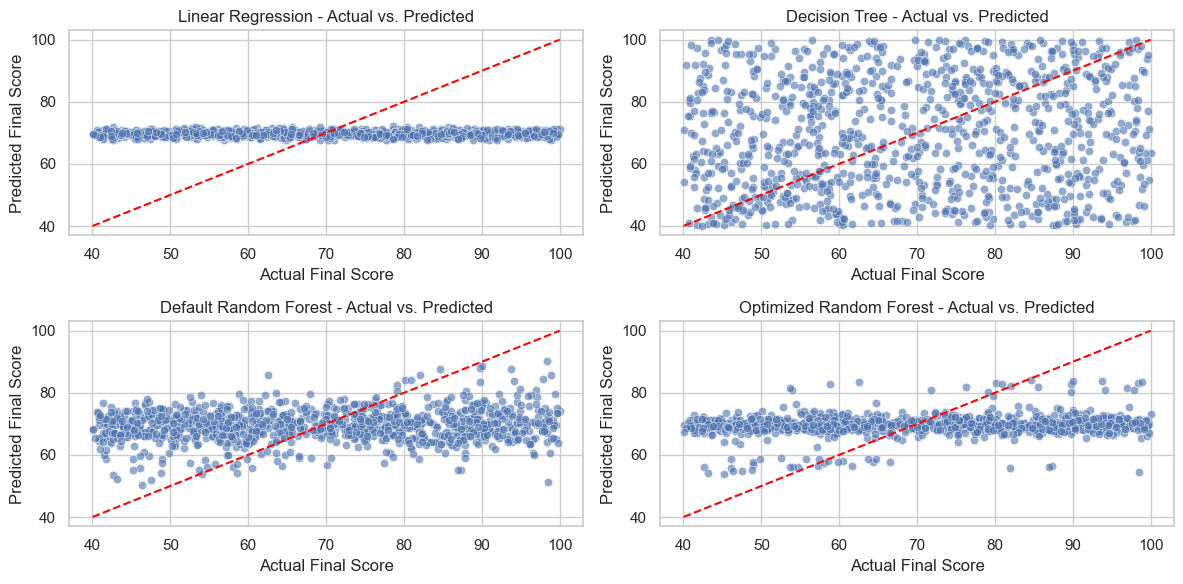

In [304]:
# Plot Predictions vs. Actual values
plt.figure(figsize=(12, 6))

# Models and predictions
models = {
    "Linear Regression": lr_model,
    "Decision Tree": dt_model,
    "Default Random Forest": rf_model,
    "Optimized Random Forest": best_rf_model
}

for i, (name, model) in enumerate(models.items(), 1):
    plt.subplot(2, 2, i)
    y_pred = model.predict(X_test)
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
    plt.title(f"{name} - Actual vs. Predicted")
    plt.xlabel("Actual Final Score")
    plt.ylabel("Predicted Final Score")

plt.tight_layout()
plt.show()


### Feature Importance (Which Features Matter Most?)
We'll use the optimized Random Forest model to find which features have the biggest impact on the Final Score.

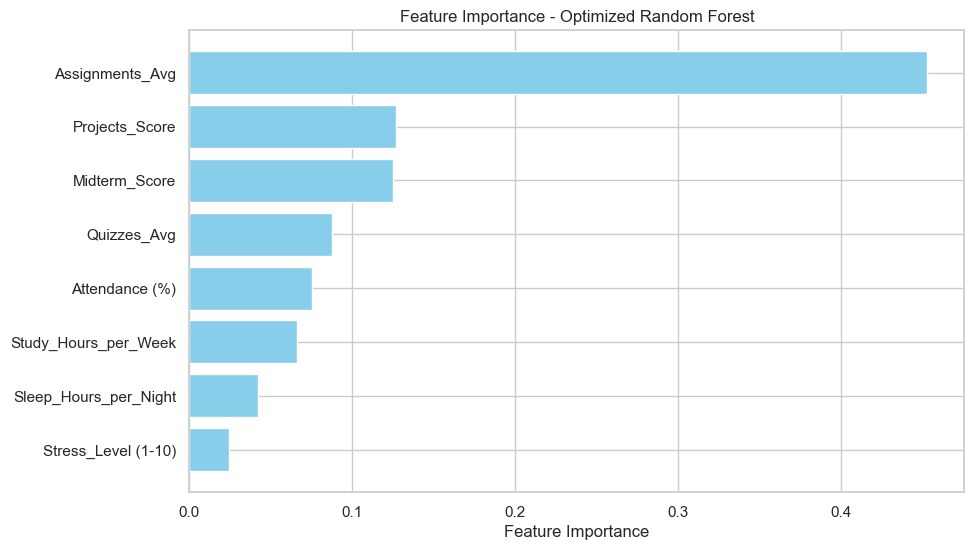

In [305]:
# Get feature importances
feature_importance = best_rf_model.feature_importances_
sorted_idx = np.argsort(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(np.array(features)[sorted_idx], feature_importance[sorted_idx], color="skyblue")
plt.xlabel("Feature Importance")
plt.title("Feature Importance - Optimized Random Forest")
plt.show()


#

  
<div style="text-align: center; background-color:rgb(155, 60, 85); padding: 10px; border-radius: 10px;">
    <span style="color: white; font-size: 40px; font-weight: bold;">📌 Summary of Student Dataset Analysis & Modeling</span>
</div>




### This summary provides a comprehensive overview of the steps taken to analyze and model the student dataset. The analysis includes data cleaning, exploratory data analysis, feature engineering, and predictive modeling. The results reveal key insights and feature importance, enabling students to make informed decisions about their academic performance. We conducted a comprehensive **data analysis, preprocessing, and predictive modeling** using the student dataset to uncover key insights affecting student performance. Below is a structured summary of the steps taken:  
---
### **🔍 1. Data Cleaning & Preprocessing**  
✔ **Handled Values** - Repeat claculating the data in Grade and Total Score 
✔ **Handled Missing Values** – Imputed missing data using mean/median for numerical columns and mode for categorical columns.  
✔ **Removed Duplicates** – Ensured dataset integrity by dropping duplicate records.  
✔ **Data Type Conversion** – Converted categorical variables to appropriate formats (e.g., numerical encoding).  
✔ **Encoding Categorical Features** – Applied Label Encoding and One-Hot Encoding to convert categorical variables such as:
Gender, Parent Education Level, Family Income Level → Label Encoding                                                                         
Extracurricular Activities, Internet Access → One-Hot Encoding                                                                                  
✔ **Remove Unccessary columns** – the columns (first_name , last_name , Email , familly_Income_level) not usefual to model .  
✔ **Outlier Detection & Treatment** – Identified outliers using box plots and IQR, then addressed them using capping methods or removal.  


---

### **📊 2. Exploratory Data Analysis (EDA)**  
✔ **Visualized Distributions** – Used histograms,pie chaert,line Plot,scatterplot ,Bar plot , KDE plots, and box plots to understand the distribution of numerical variables.  
✔ **Correlation Analysis** – Generated a heatmap to assess relationships between features (e.g., attendance, study hours, and final scores).  
✔ **Impact of Factors**:  
   - Higher **attendance** positively correlated with **higher final scores**.  
   - Increased **study hours** resulted in **better performance**.  
   - High **stress levels** negatively impacted grades, especially when combined with poor sleep.  
✔ **Comparison by Gender** – Analyzed differences in performance metrics across gender groups using bar and pie charts.  


---

### **📈 3. Predictive Modeling**  
✔ **Trained Multiple Models** – Implemented **Linear Regression, Decision Tree, and Random Forest** for predicting student performance.  
✔ **Hyperparameter Tuning** – Optimized **Random Forest Regressor** using **RandomizedSearchCV** for better efficiency.  
✔ **Model Evaluation** – Compared models based on **Mean Squared Error (MSE)** and **R² Score**, selecting the best-performing model.  
✔ **Feature Importance Analysis** – Identified key factors influencing student scores using Random Forest's feature importance.  

---

### **📌 Key Findings & Insights**  
📍 **Attendance & Study Hours Matter** – Students with **higher attendance and more study hours** consistently performed better.  
📍 **Stress & Sleep Impact Performance** – High stress combined with low sleep **led to lower scores**.  
📍 **Parent Education & Internet Access** – Students with **higher parent education levels** and **internet access at home** showed better academic performance.  

---
### **📊 Conclusion & Future Work**
The analysis revealed significant factors influencing student performance, including attendance, study hours, stress levels, and parental
education. These insights can inform targeted interventions to improve student outcomes. Future work could involve exploring additional factors
  to improve student performance, such as incorporating technology-based assessments, creating engaging learning environments, and promoting academic support.
  * **Students aiming for higher grades should focus on excelling in final exams and projects.**
  
* **Study time alone does not guarantee better performance, suggesting that quality of study matters more than quantity.**
  
* **Digital Access Matters – Bridging the digital divide can significantly impact student performance.**

* **Stress Management is Crucial – Academic stress does not always lead to better performance, so wellness programs should be prioritized.**

* **Extracurriculars Provide Indirect Benefits – While not statistically significant in grades, they develop crucial skills.**
  

#

---

<div style="text-align: center;">
  <p>Thank you for your time and efforts!</p>
  <h3>By: Youssef Bassiony Abdlah</h3>
  <div style="display: inline-block;">
    <a href="yossf.abdla311@gmail.com" title="Redirect to e-mail">
      <img src="objects/Pic/icons8-gmail-logo-94.png"  alt="e-mail" style="width: 50px; height: 50px; margin: 0 10px;">
    </a>
    <a href="https://wa.me/+201001725166/" title="Redirect to What'sApp">
      <img src="objects/Pic/icons8-whatsapp-48.png" alt="What'sApp" style="width: 50px; height: 50px; margin: 0 10px;">
    </a>
    <a href="https://www.linkedin.com/in/youssef-bassiony/" title="Redirect to LinkedIn">
      <img src="objects/Pic/icons8-linkedin-48.png" alt="LinkedIn" style="width: 50px; height: 50px; margin: 0 10px;">
    </a>
  </div>
</div>
